In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [3]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches

In [4]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/5sec_50%overlap/data"

train_path = os.path.join(DATA_DIR, "SBP_FTEST_train.csv")
val_path   = os.path.join(DATA_DIR, "SBP_FTEST_val.csv")
test_path  = os.path.join(DATA_DIR, "SBP_FTEST_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (829483, 16)
Val:   (104736, 16)
Test:  (105176, 16)


In [5]:
TARGET = "SBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (829483, 15)
y_train: (829483,)
X_val:   (104736, 15)
y_val:   (104736,)
X_test:  (105176, 15)
y_test:  (105176,)


In [6]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_50%overlap/data/SBP_FTEST_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(9271840, 17)
    vpg_iqr  vpg_skewness  vpg_energy_iqr  apg_zero_crossing_rate  \
0  1.749678     -0.521950       -1.100212               -0.931305   
1  1.591203     -0.303971       -1.147739                0.472676   
2  1.771377     -0.268875       -1.170170                0.940669   
3  2.261320     -0.565650       -1.058390                0.472676   
4  2.276123     -0.802773       -1.048784               -0.580310   

   apg_energy_iqr   ppg_iqr  vpg_shannon_entropy  apg_skewness  \
0       -0.599843  0.502455             0.111919      2.778702   
1       -0.530067  0.681538            -0.027732      2.593202   
2       -0.416837  0.977237             0.010860      2.506303   
3       -0.445621  1.027572             0.326498      2.393785   
4       -0.535254  1.041598             0.735309      2.502233   

   apg_shannon_entropy  vpg_kte_iqr   apg_iqr  vpg_energy_skewness  \
0            -0.246774    -0.677617 -0.418230            -0.227671   
1            -0.179999    -0.60585

In [7]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [8]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [9]:
print("SBP min:", y_train.min())
print("SBP max:", y_train.max())
print("SBP mean:", y_train.mean())
print("SBP std:", y_train.std())

print("SBP > 80:", np.sum(y_train > 80))
print("SBP > 90:", np.sum(y_train > 90))
print("SBP > 100:", np.sum(y_train > 100))

SBP min: 72.48465074023241
SBP max: 199.3622907516529
SBP mean: 129.94175380628658
SBP std: 22.028076535061036
SBP > 80: 828714
SBP > 90: 816812
SBP > 100: 768831


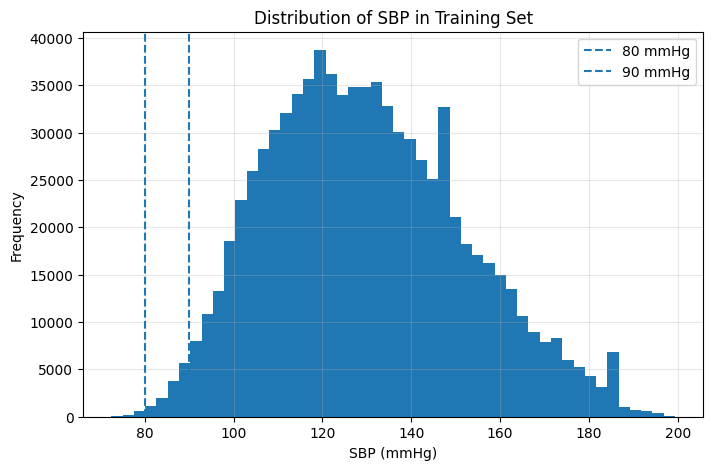

In [10]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("SBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of SBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: SBP
RMSE: 21.2387
MSE : 451.0825
R²  : 0.1455
MAE : 16.9849


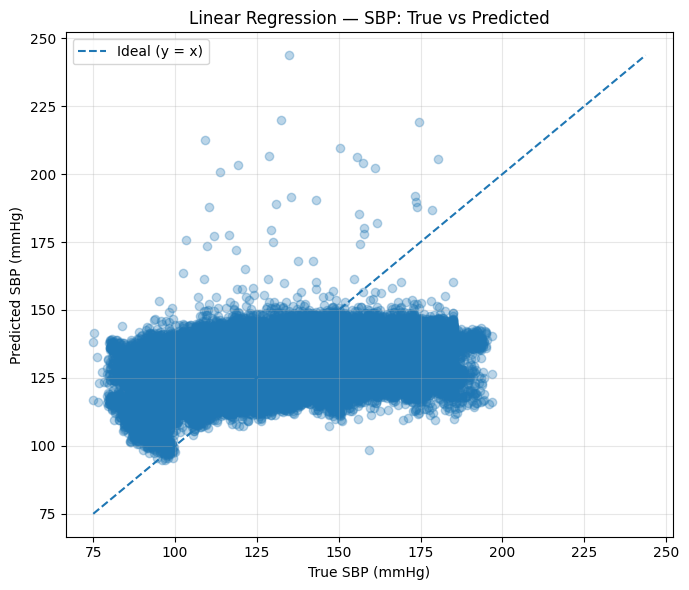

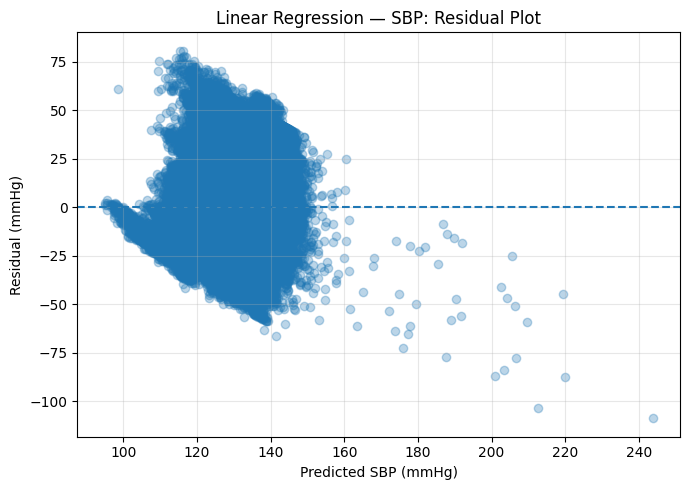

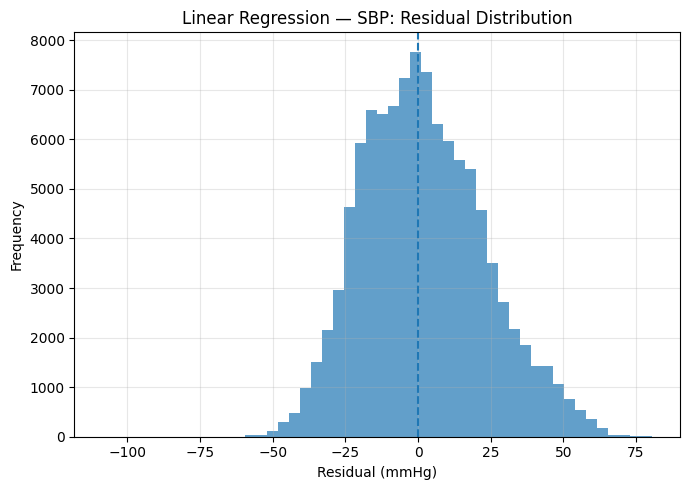

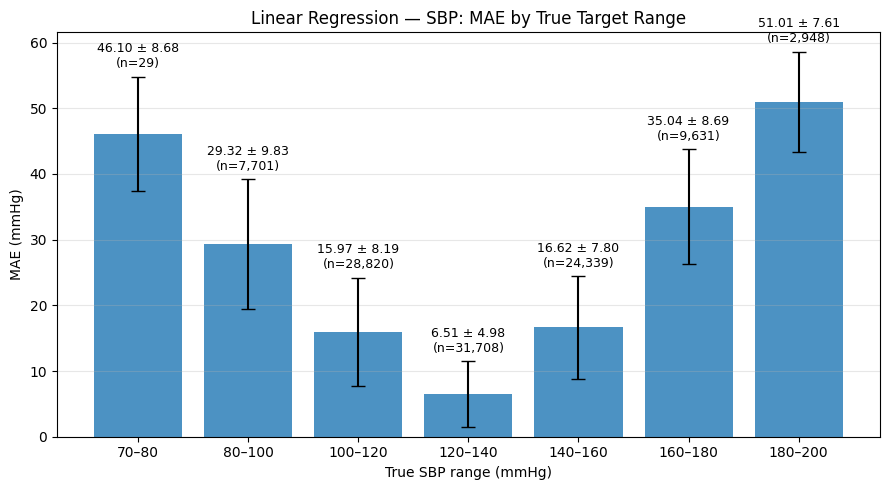

In [11]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 119.9102
MSE : 14378.4447
R²  : -32.6415
MAE : 25.9998


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


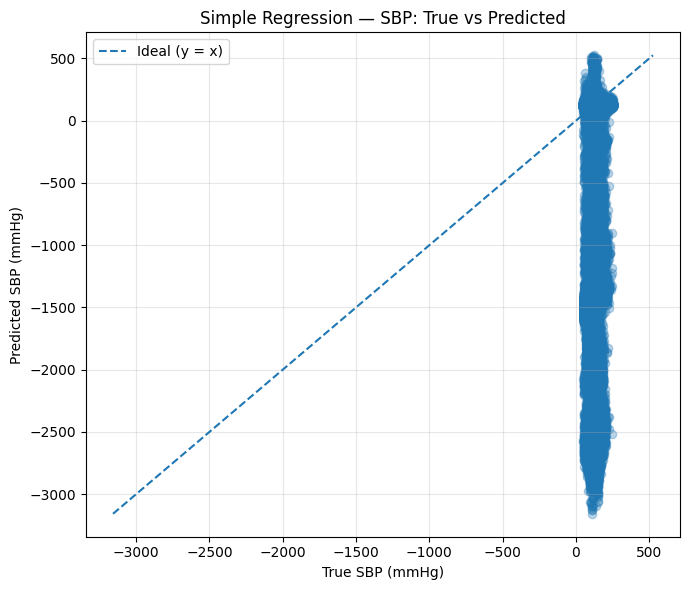

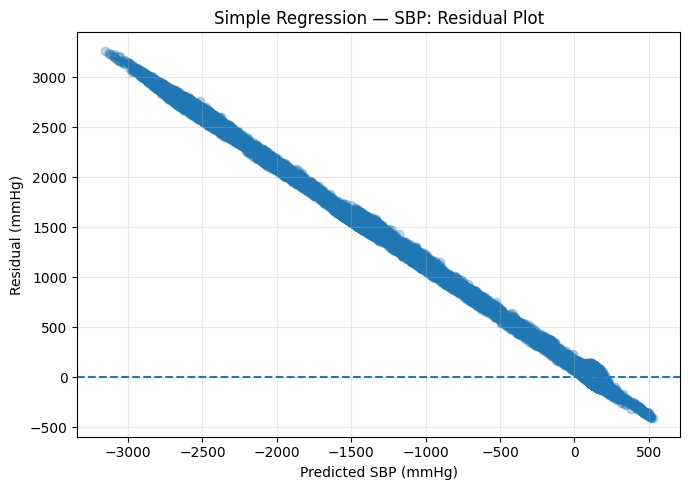

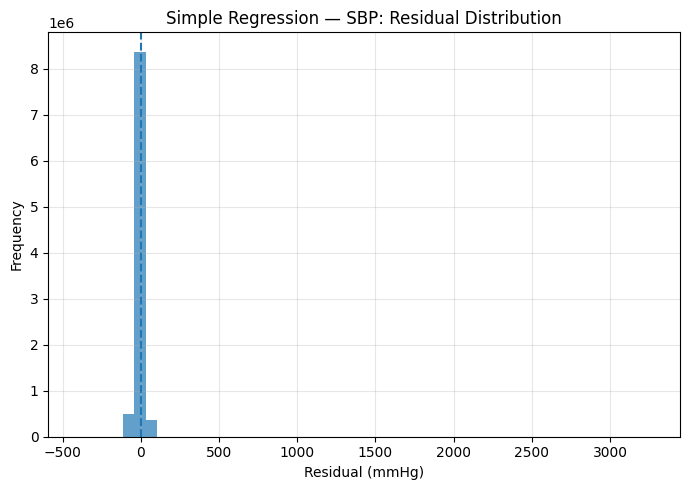

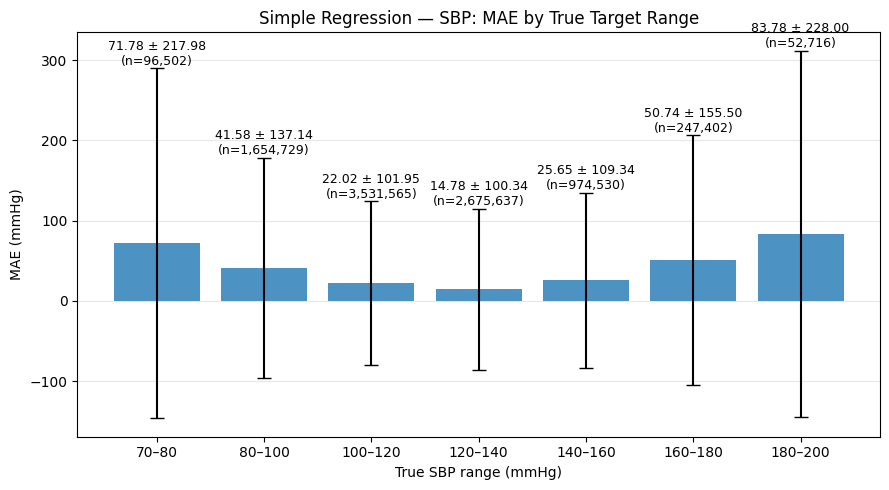

In [12]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — SBP
---------------------------------------------
RMSE: 20.3331
MSE : 413.4366
R²  : 0.2168
MAE : 16.1827


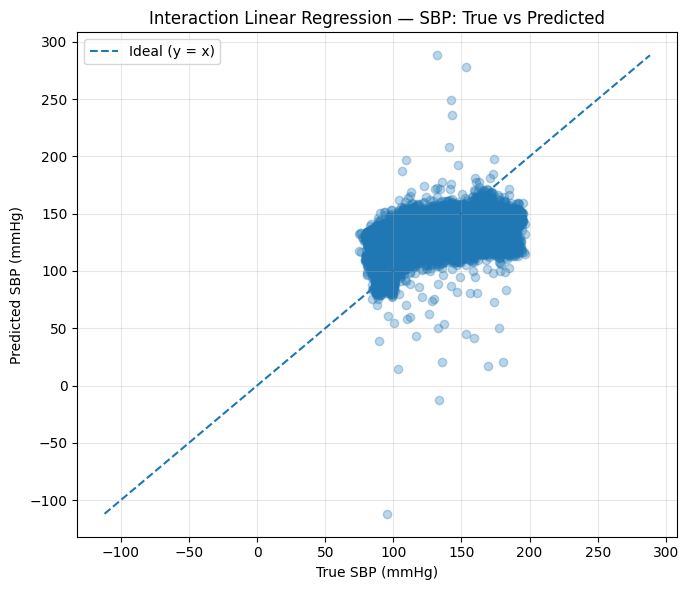

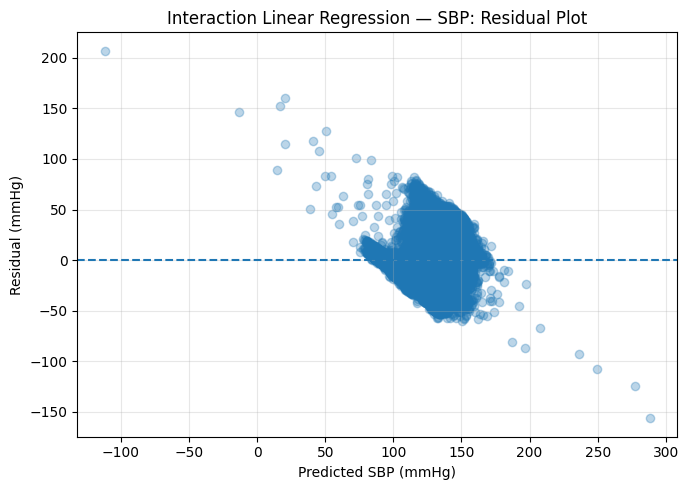

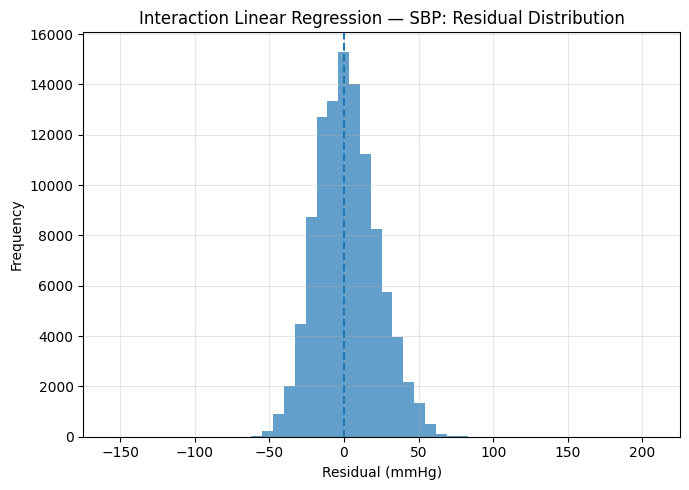

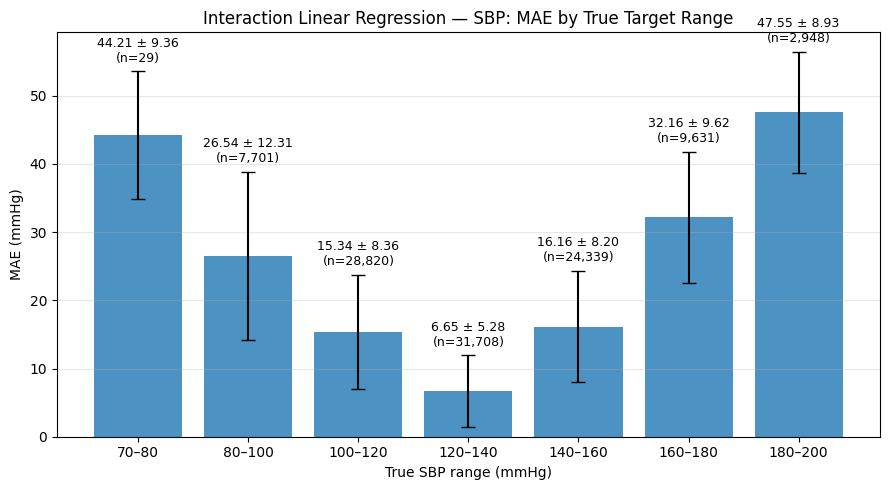

In [13]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 3374.3499
MSE : 11386237.1294
R²  : -26639.5642
MAE : 232.7967


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


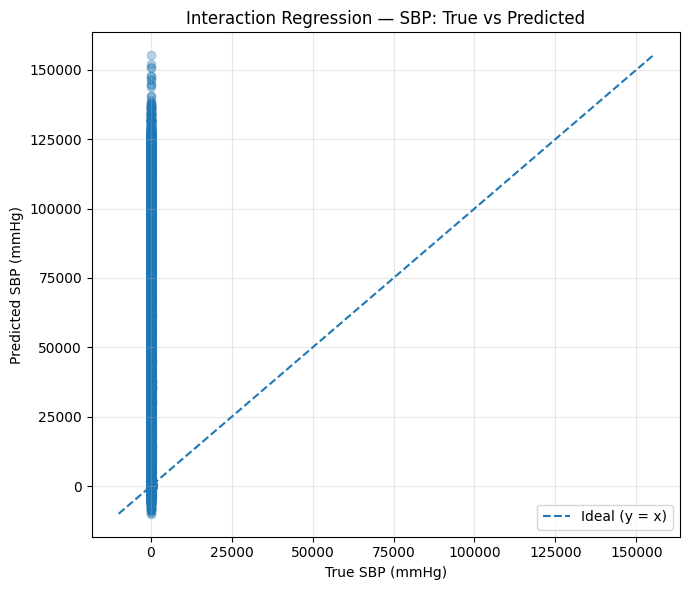

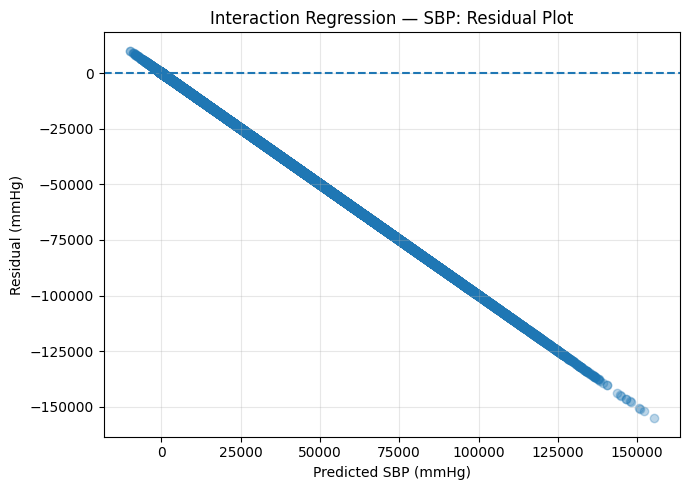

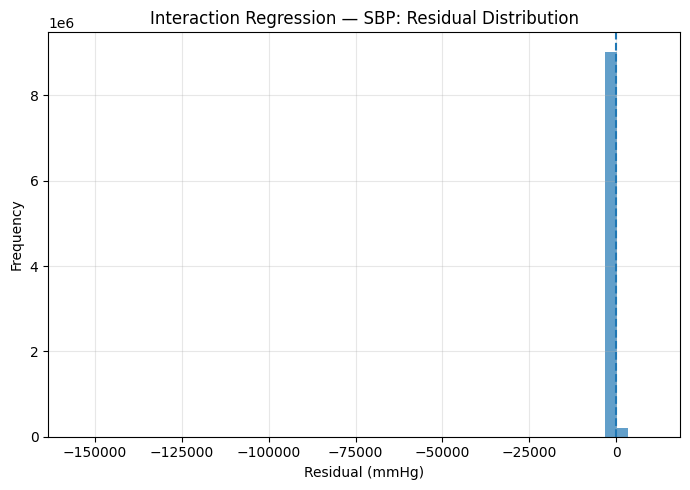

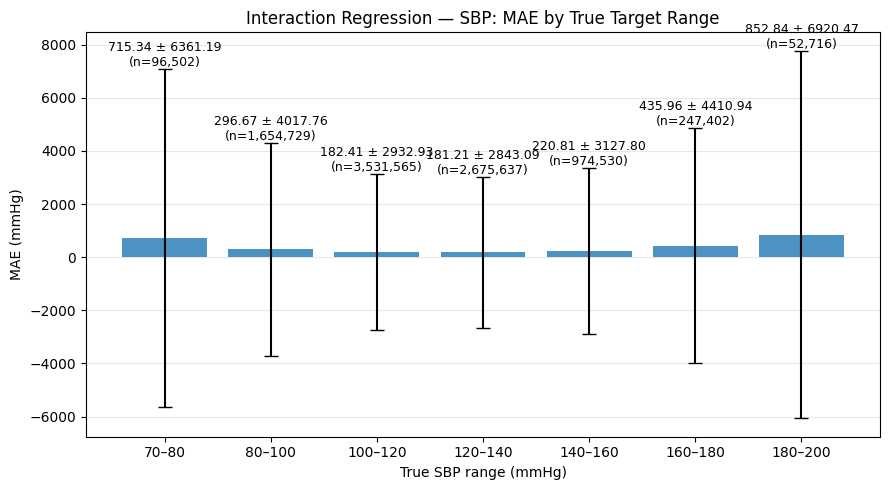

In [14]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — SBP
----------------------------------------
RMSE: 21.2610
MSE : 452.0291
R²  : 0.1437
MAE : 16.9729


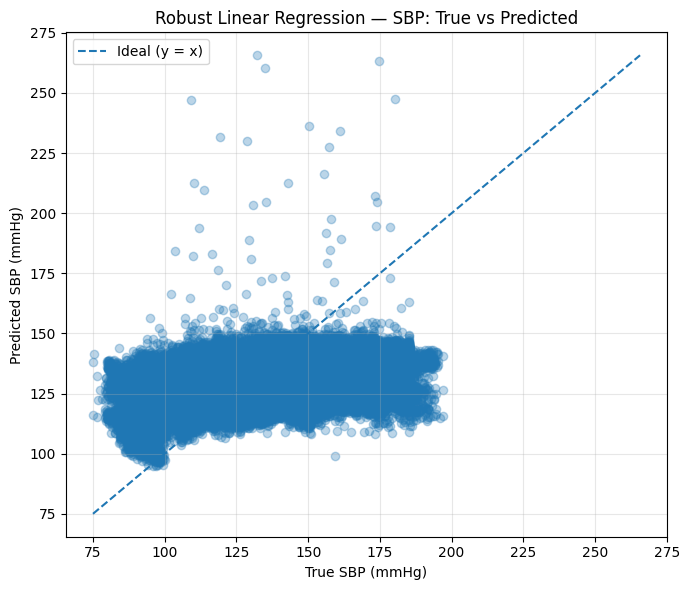

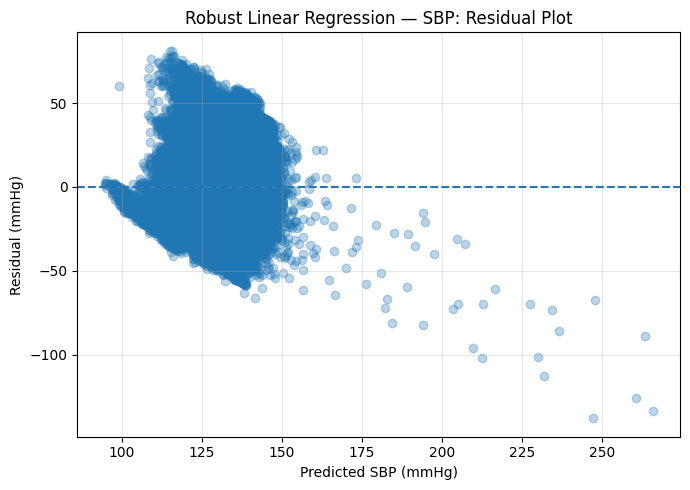

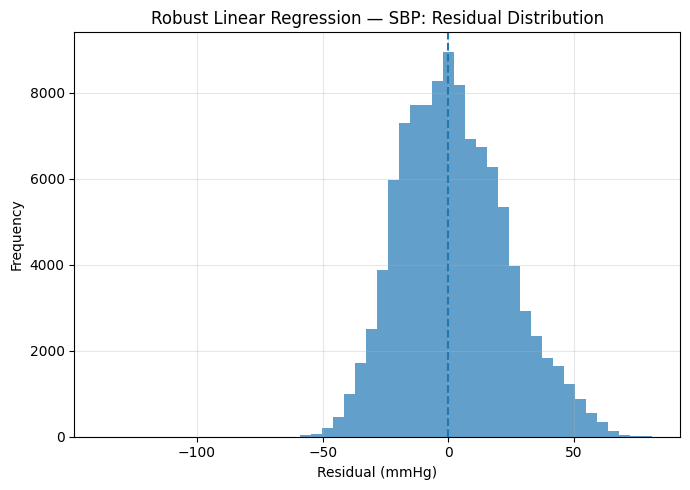

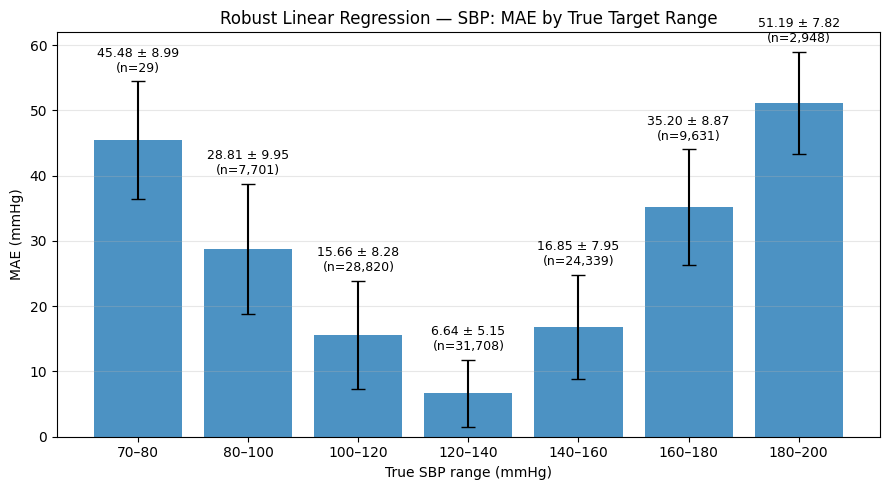

In [15]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 123.2774
MSE : 15197.3229
R²  : -34.5574
MAE : 31.2231


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


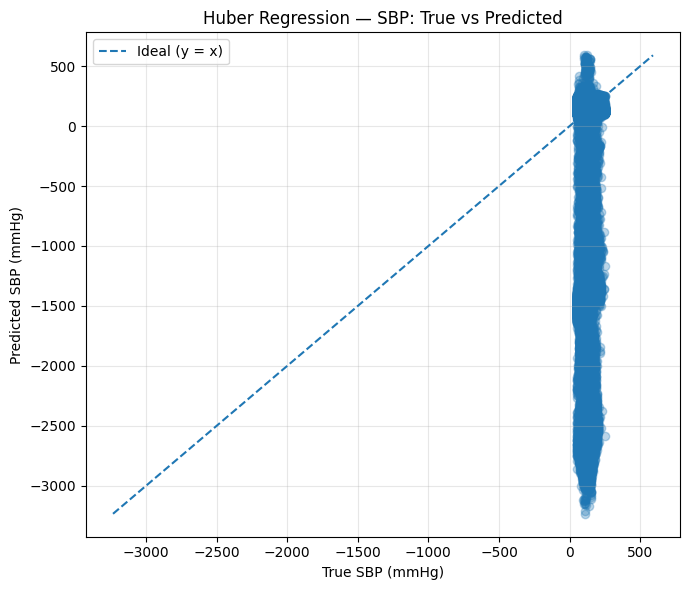

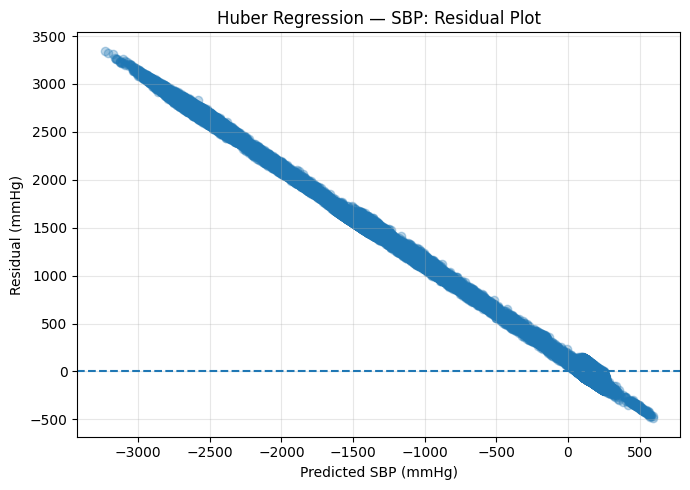

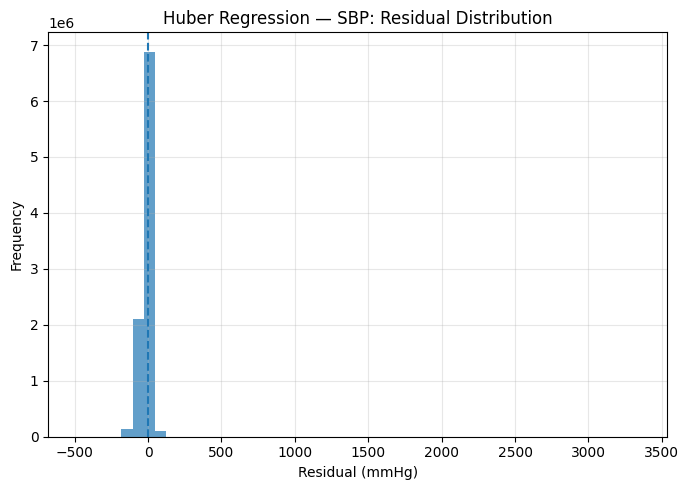

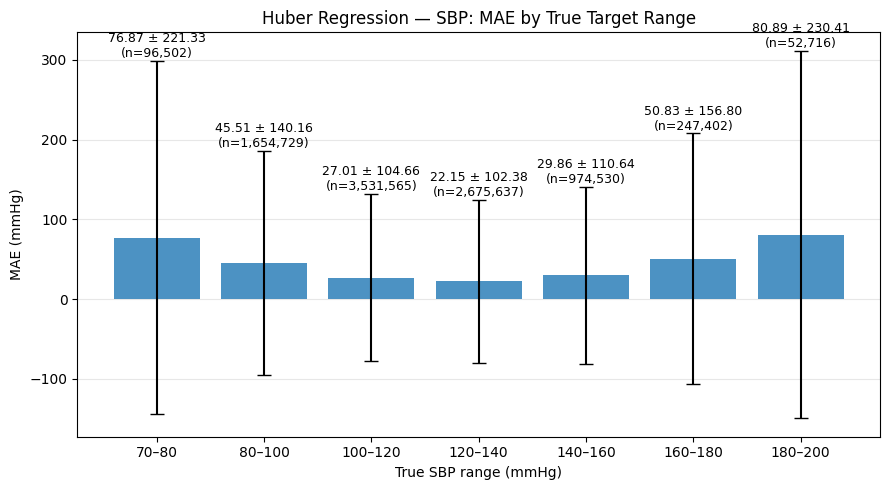

In [16]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — SBP
--------------------------------
RMSE: 20.3984
MSE : 416.0952
R²  : 0.2117
MAE : 15.9096


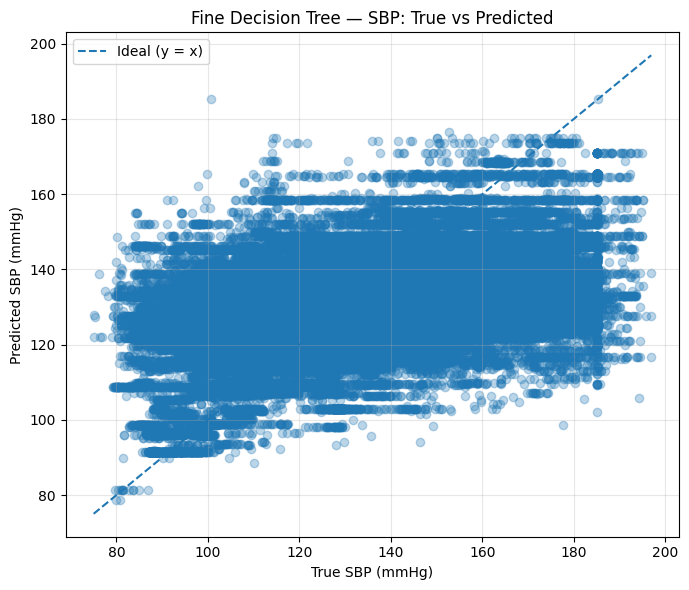

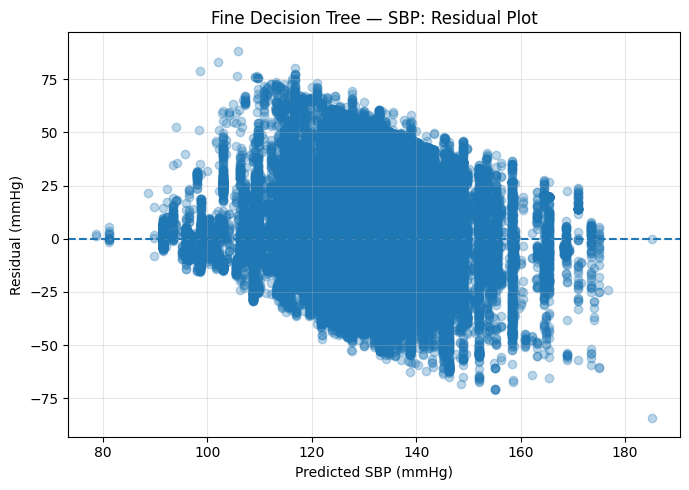

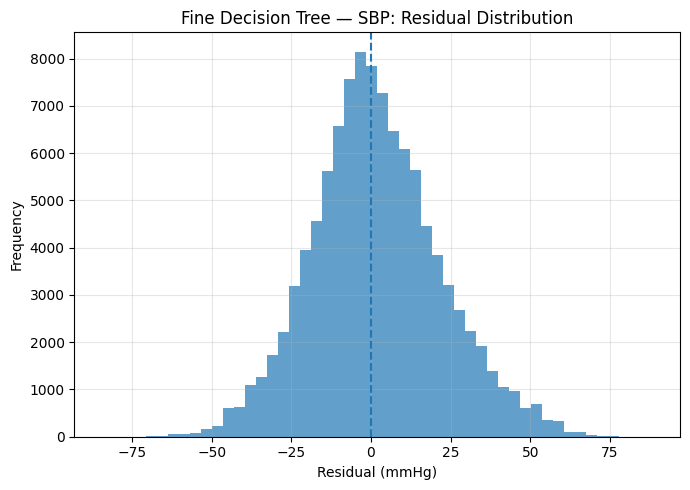

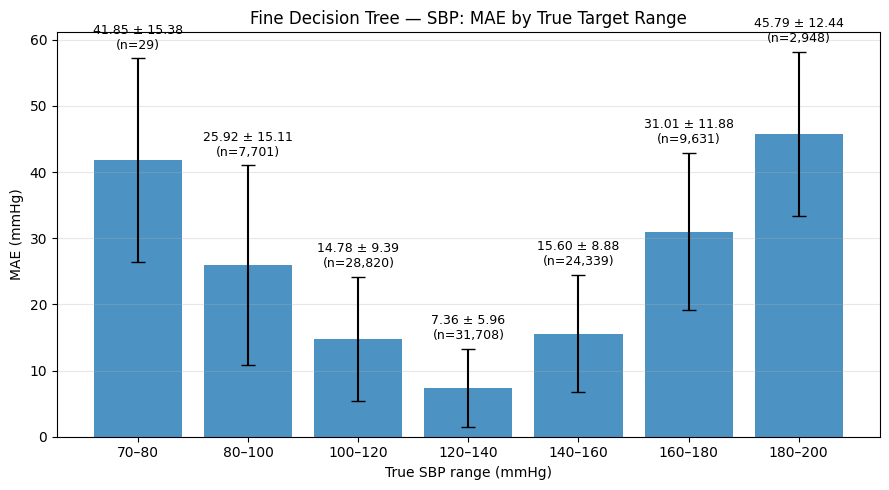

In [17]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 23.7028
MSE : 561.8207
R²  : -0.3145
MAE : 18.9818


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


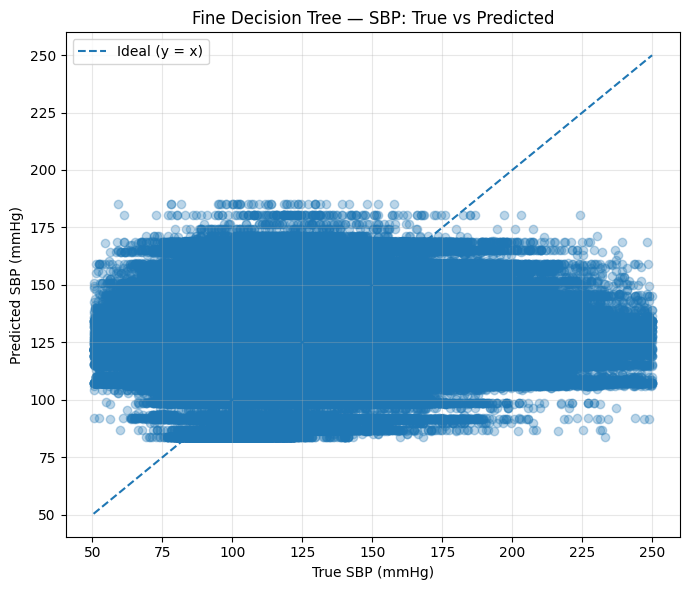

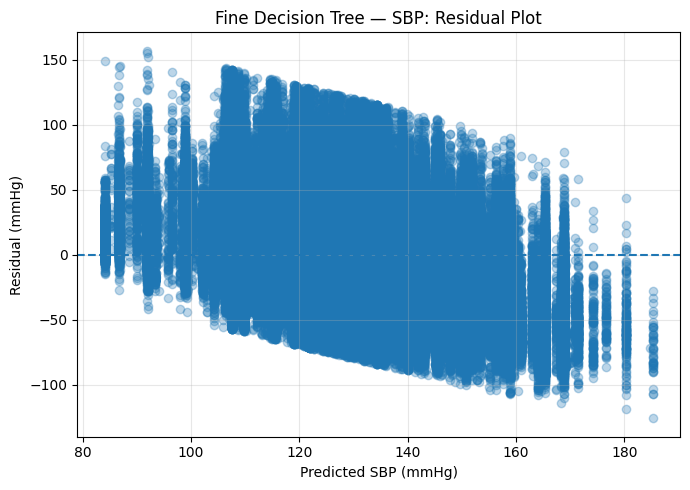

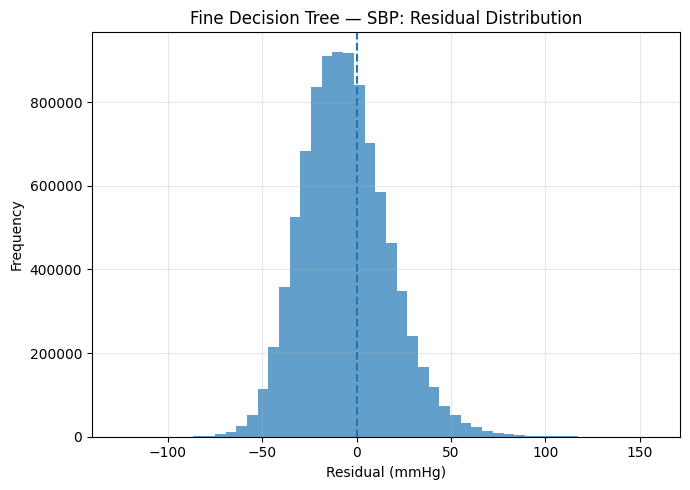

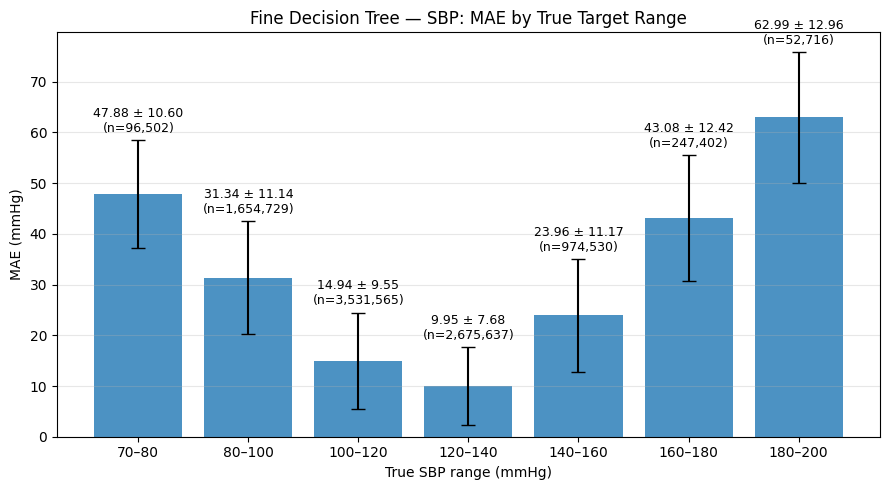

In [18]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — SBP
----------------------------
RMSE: 17.5183
MSE : 306.8897
R²  : 0.4186
MAE : 13.1099


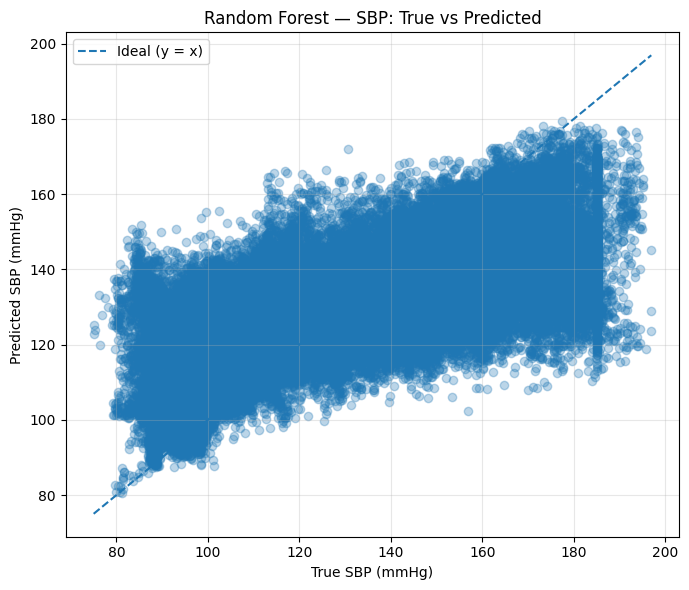

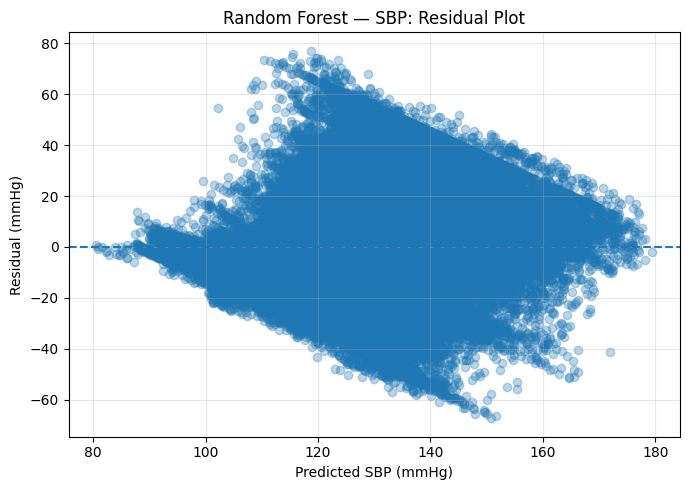

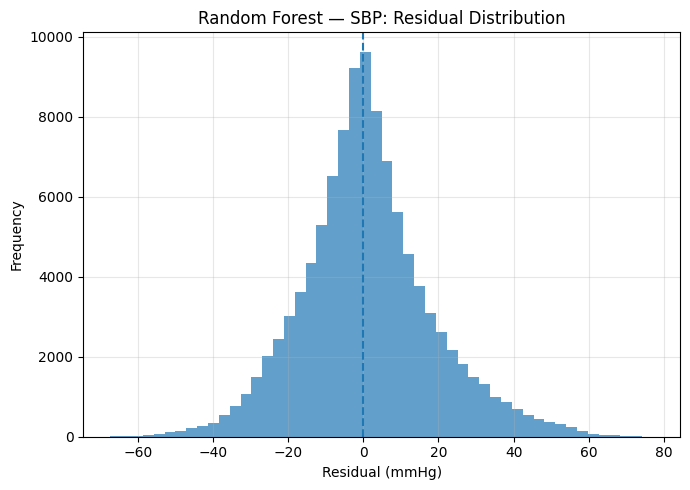

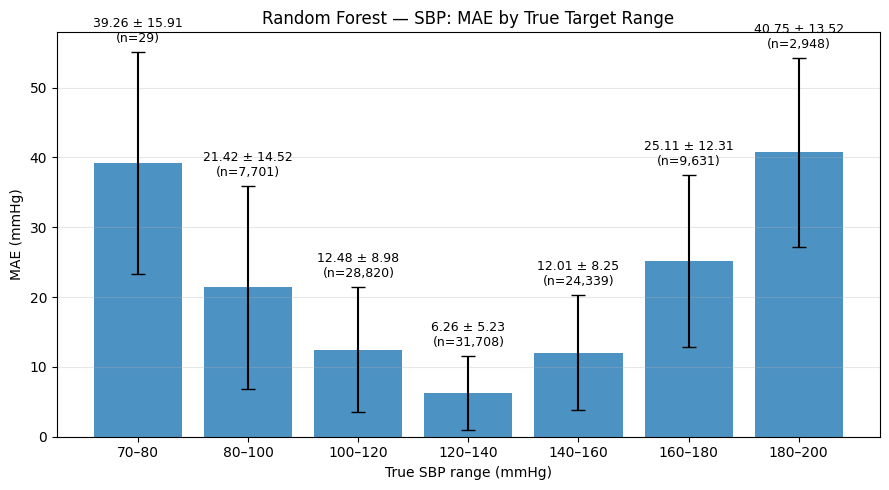

In [19]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 25.2416
MSE : 637.1369
R²  : -0.4907
MAE : 20.9186


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


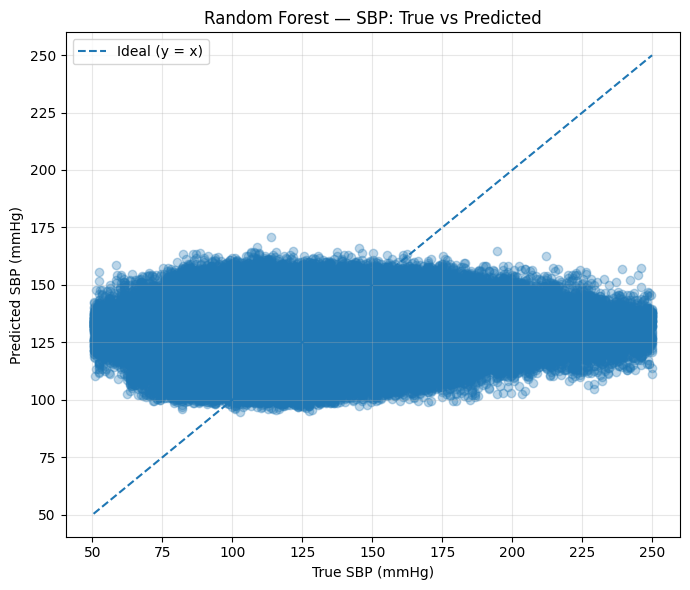

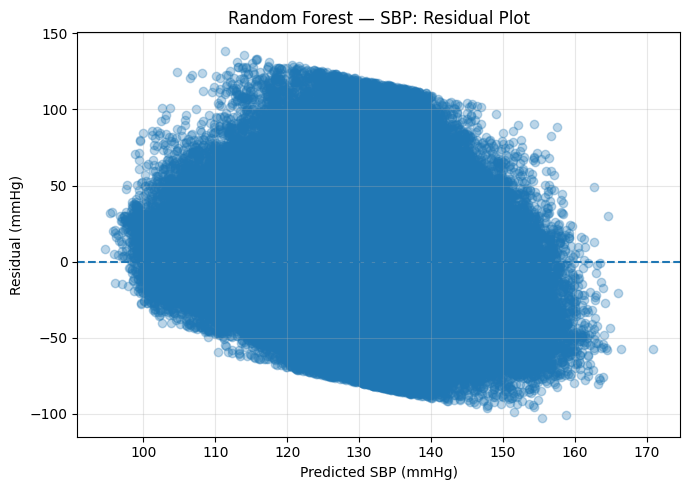

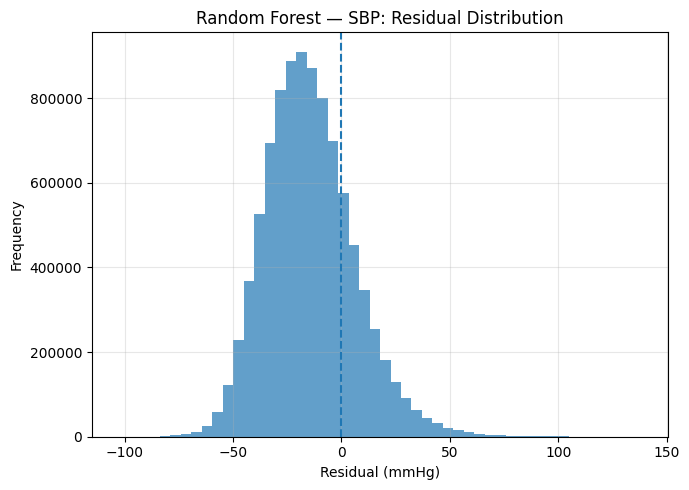

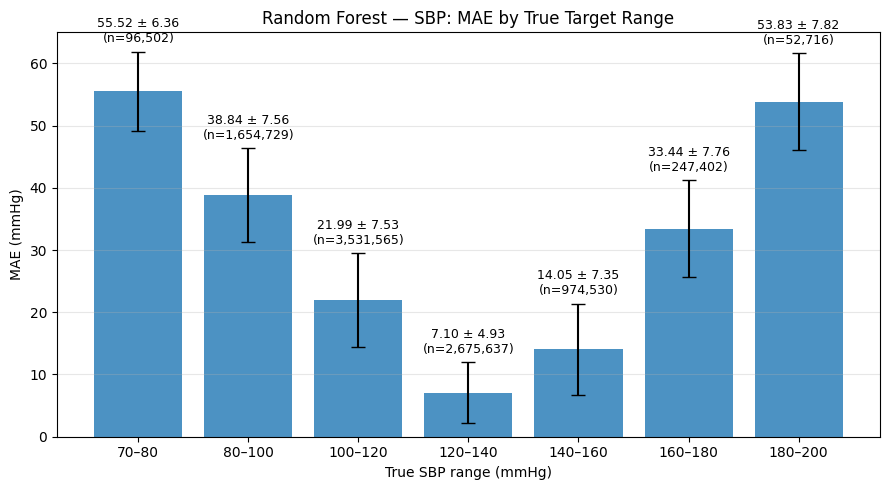

In [20]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — SBP
--------------------------------------
RMSE: 17.3858
MSE : 302.2657
R²  : 0.4274
MAE : 12.8578


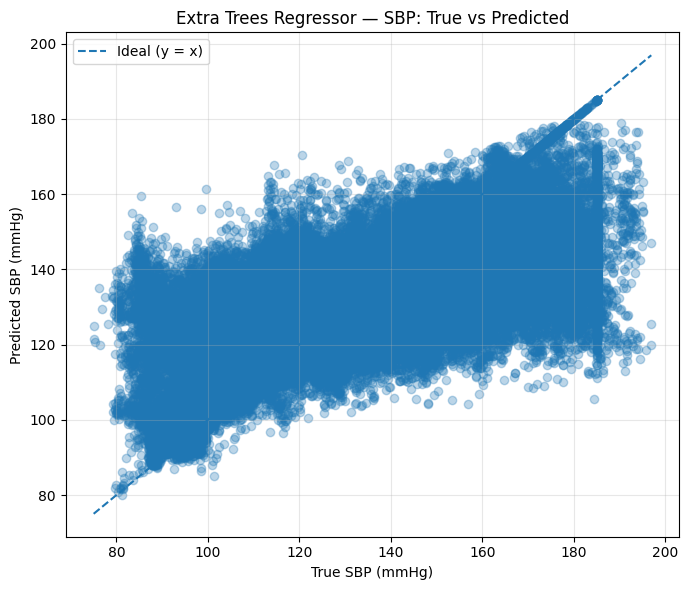

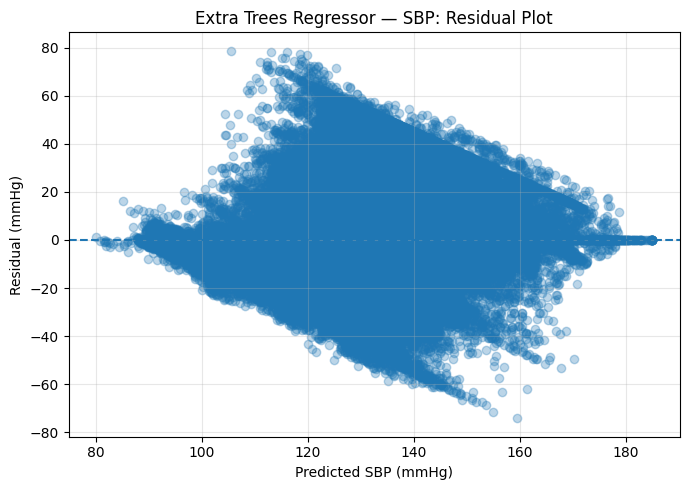

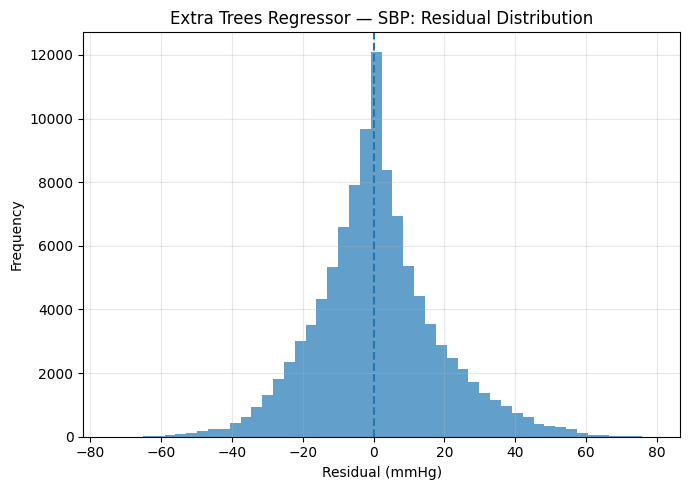

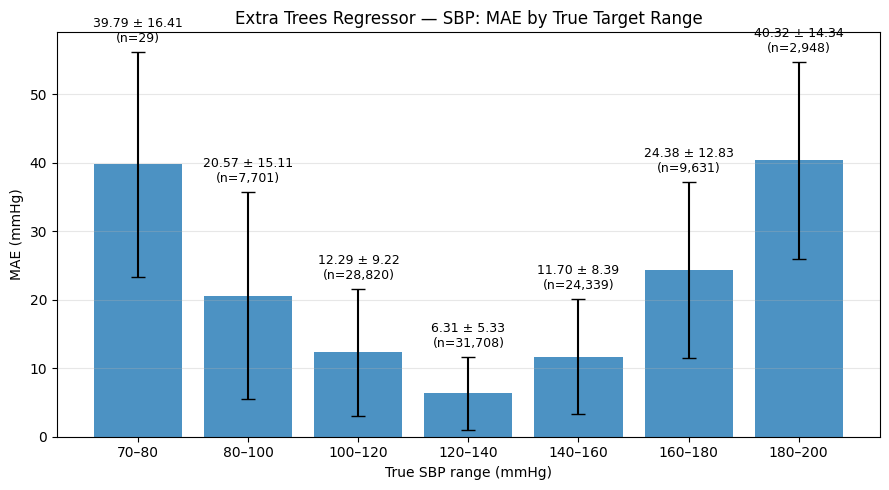

In [21]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 26.3110
MSE : 692.2713
R²  : -0.6197
MAE : 21.9148


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


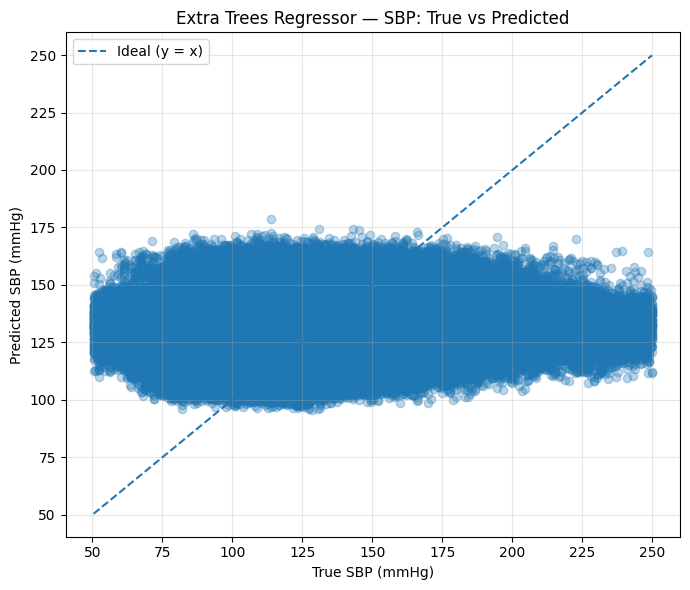

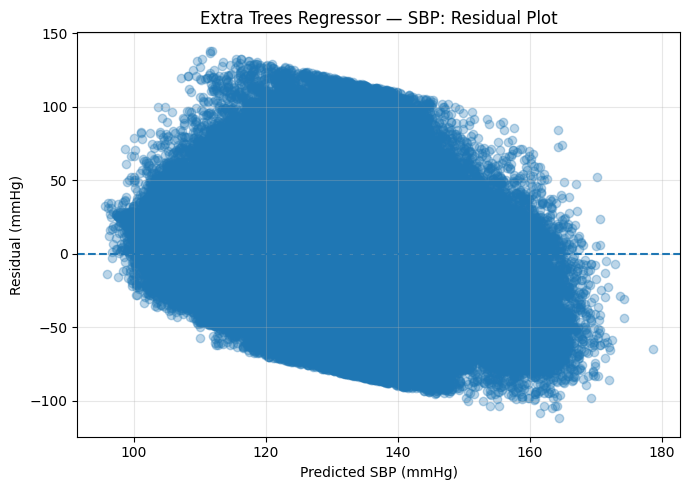

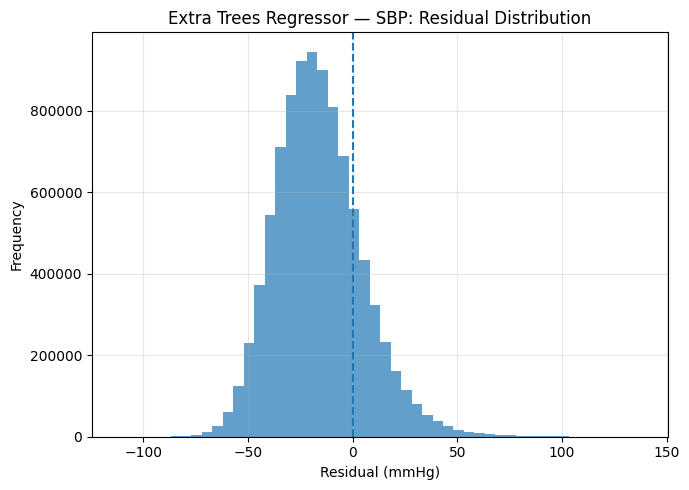

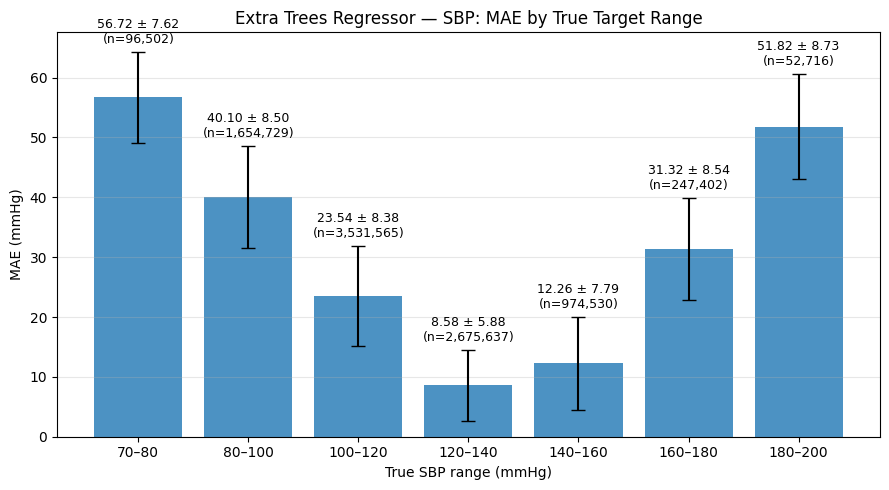

In [22]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — SBP
---------------------
RMSE: 18.9003
MSE : 357.2228
R²  : 0.3233
MAE : 14.6662


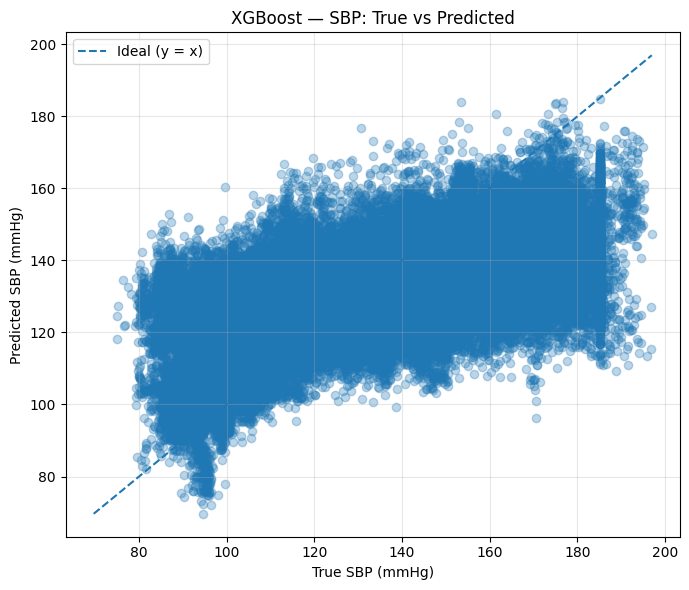

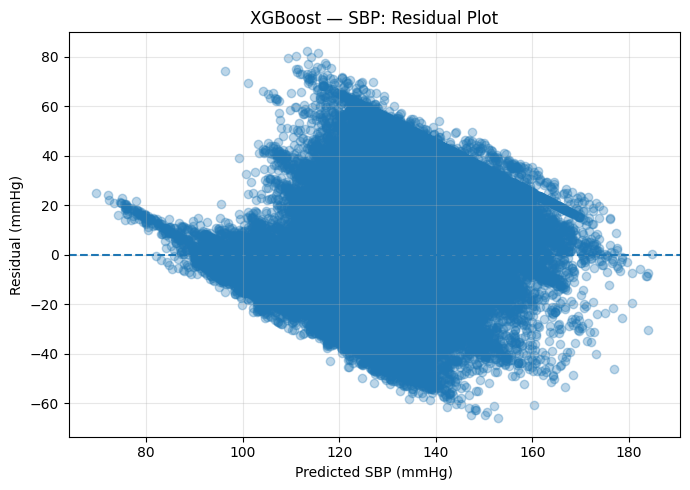

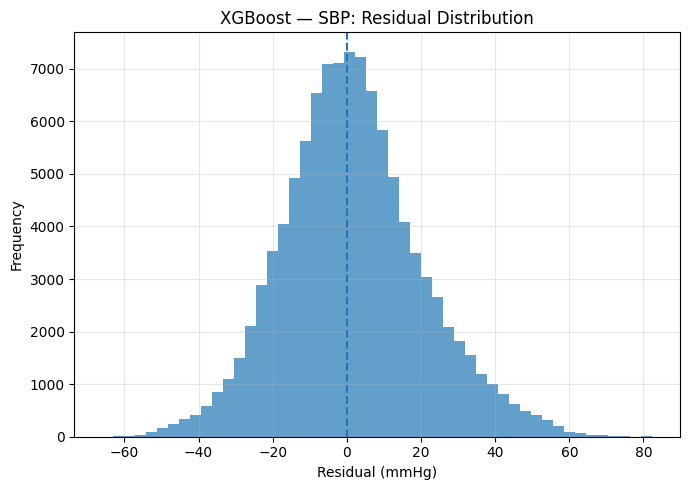

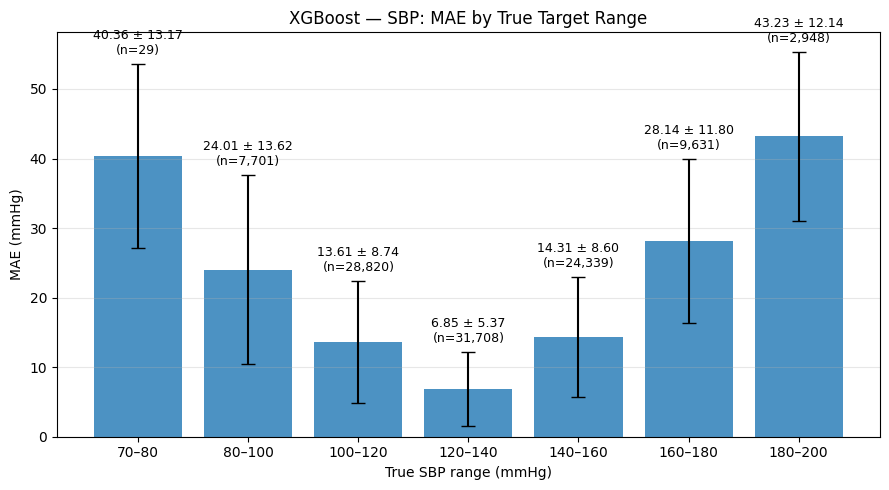

In [23]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 27.6027
MSE : 761.9071
R²  : -0.7826
MAE : 22.7348


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


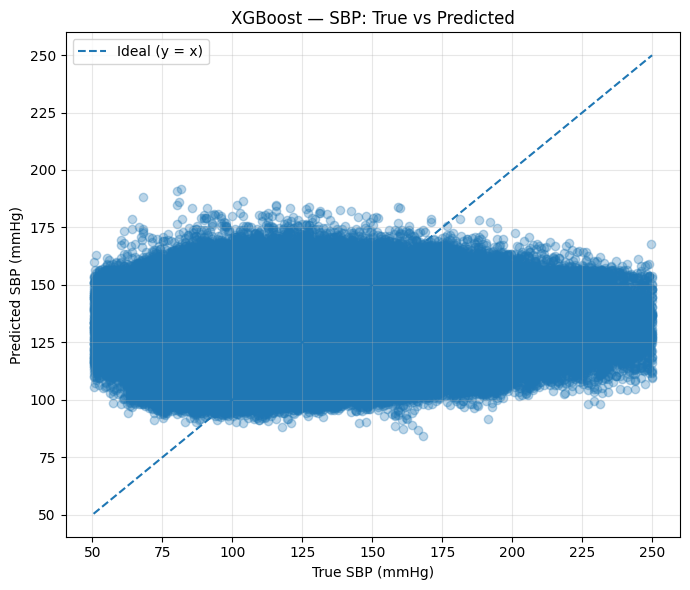

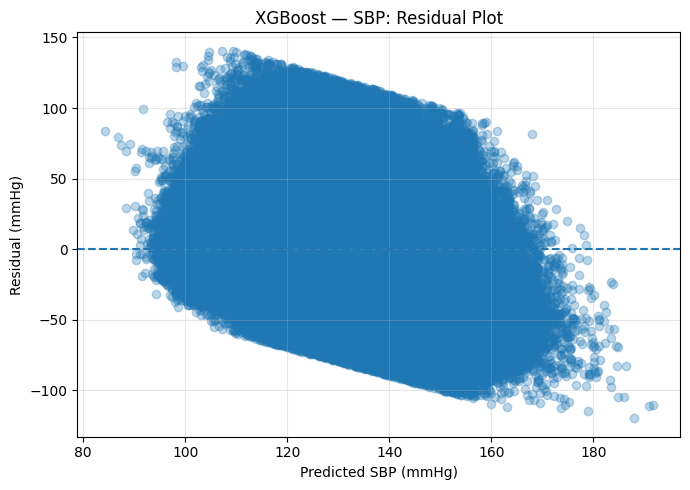

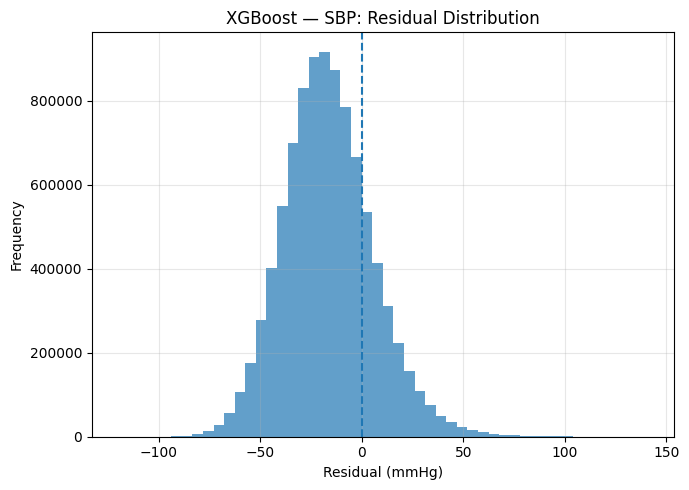

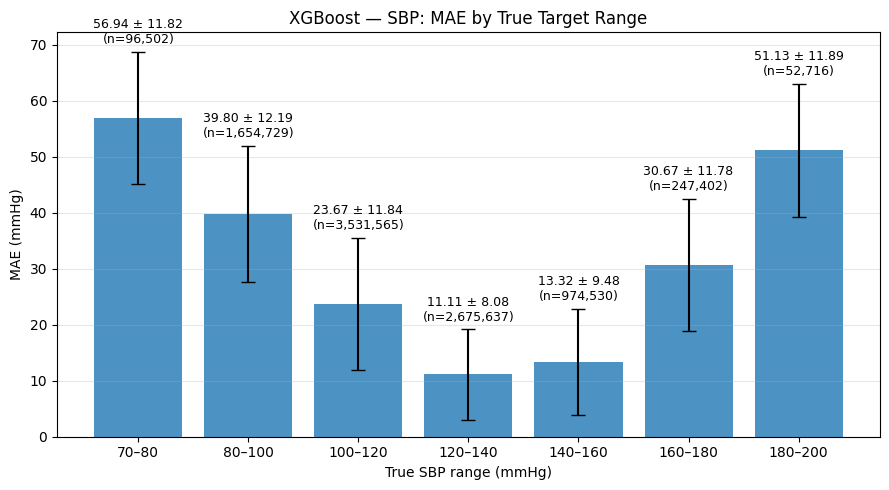

In [24]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   1.6s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   1.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   1.8s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   1.9s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   2.0s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   2.2s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   2.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   2.8s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total time=   1.5s
[CV] END learning_rate=0.05, max_depth=10, n_estimators=100, num_leaves=15; total ti

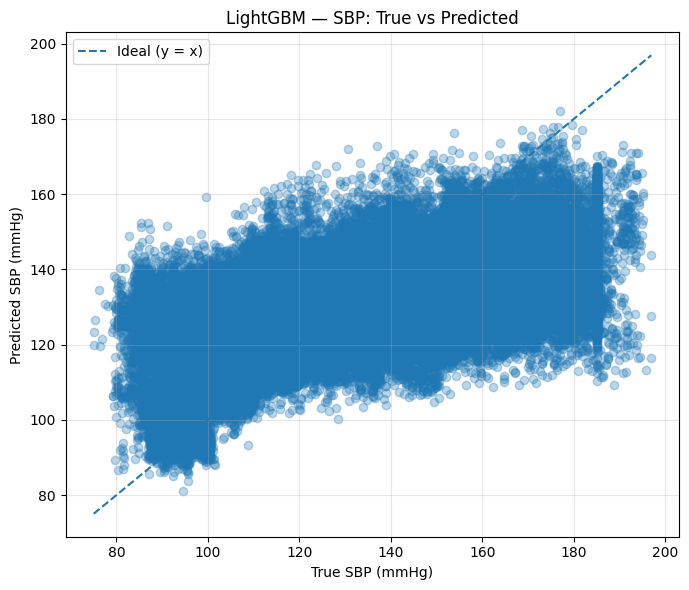

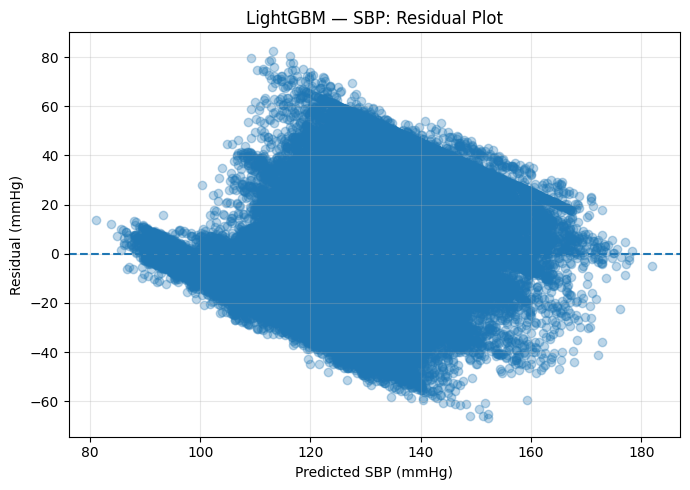

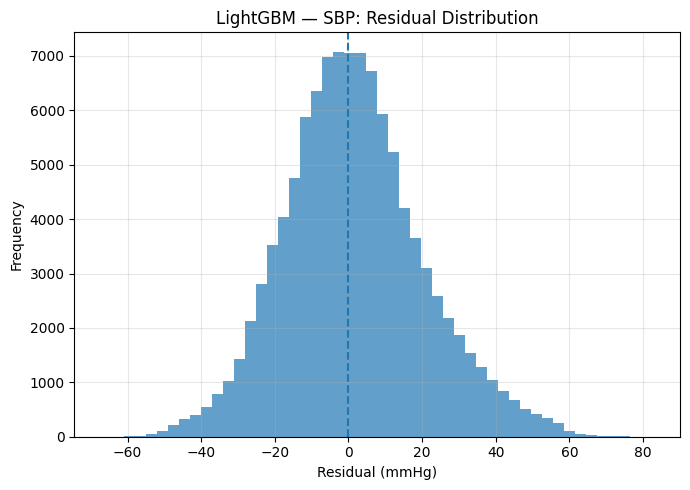

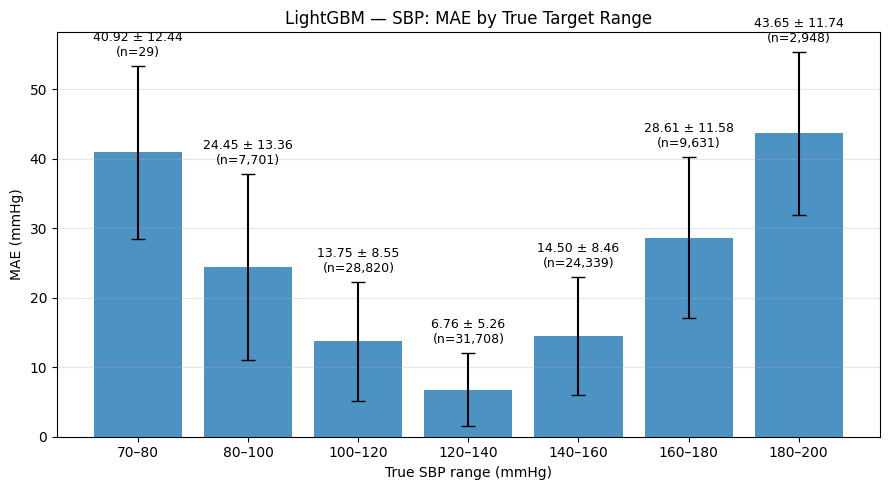

In [25]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 24.6724
MSE : 608.7274
R²  : -0.4242
MAE : 20.1917


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


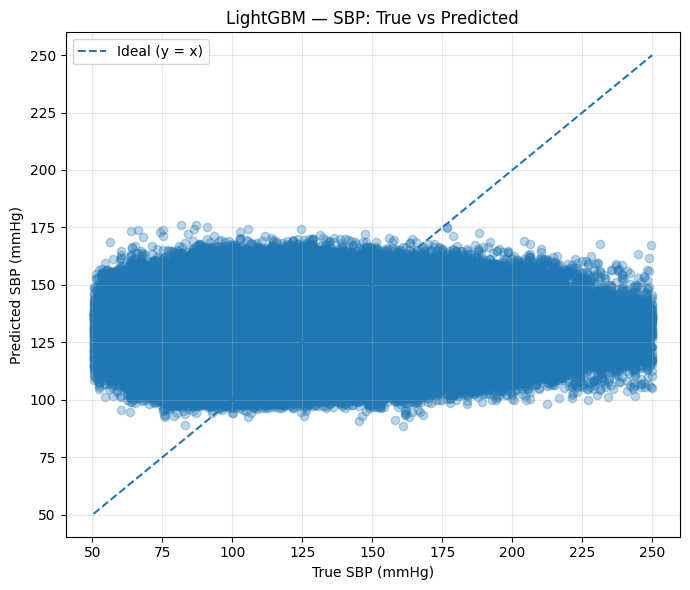

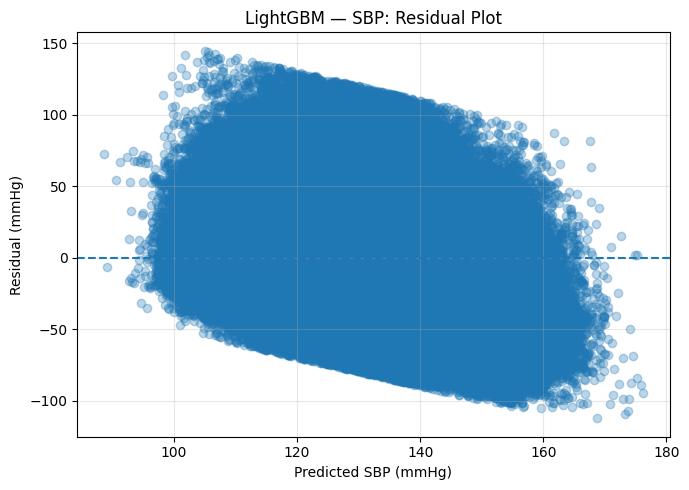

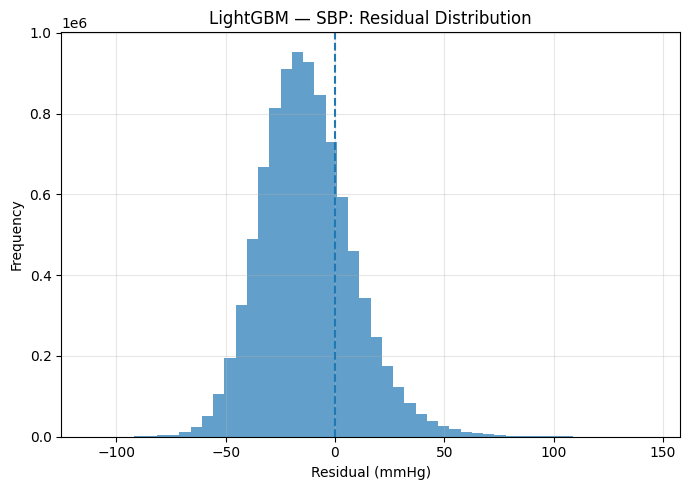

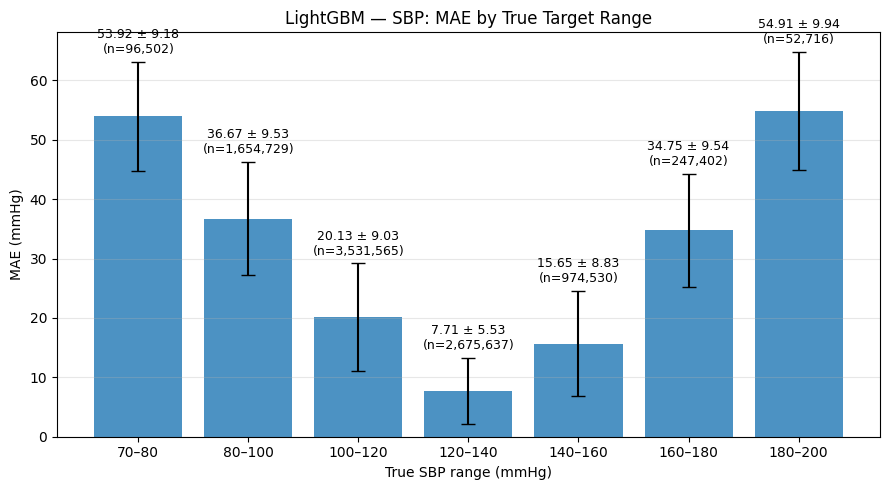

In [26]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Best parameters:
{'kernel': 1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — SBP
--------------------------------
RMSE: 19.8939
MSE : 395.7676
R²  : 0.2503
MAE : 15.4825


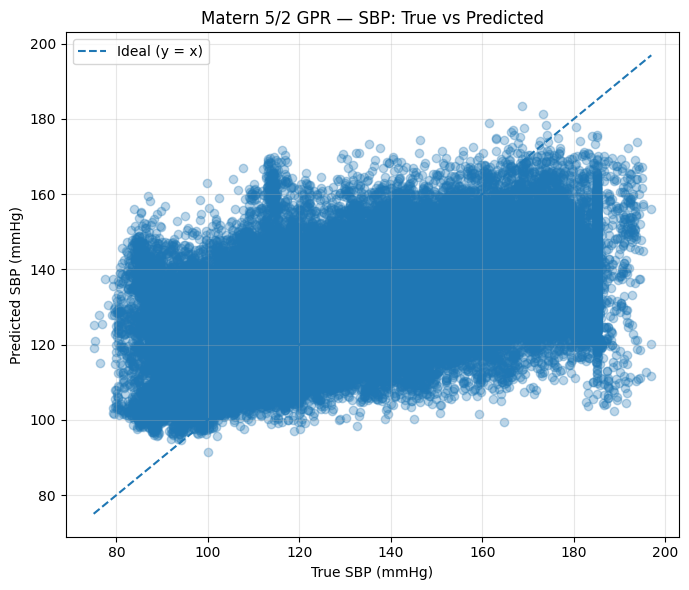

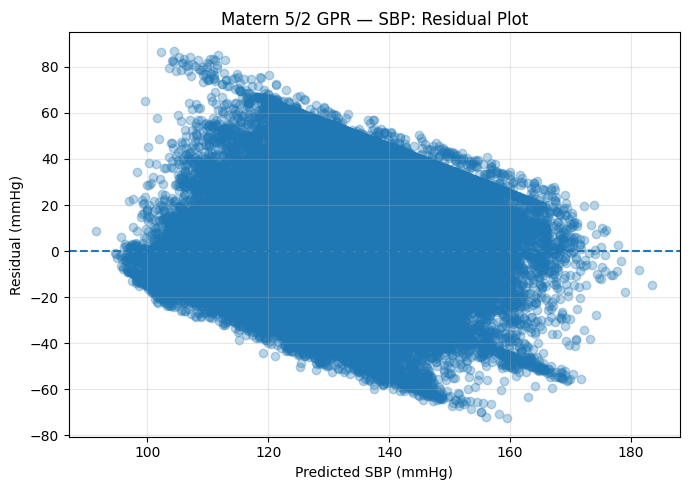

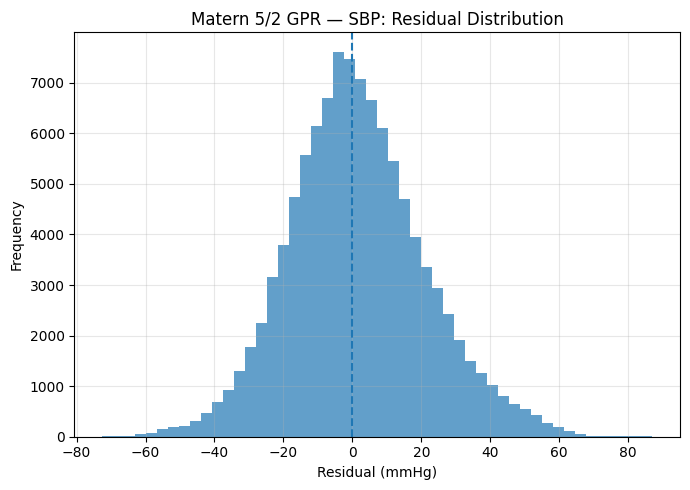

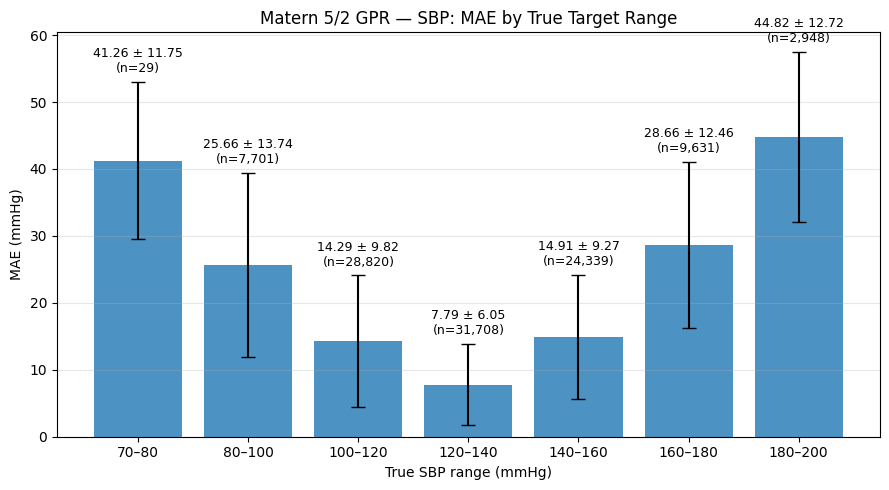

In [27]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 23.8038
MSE : 566.6210
R²  : -0.3257
MAE : 19.5700


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


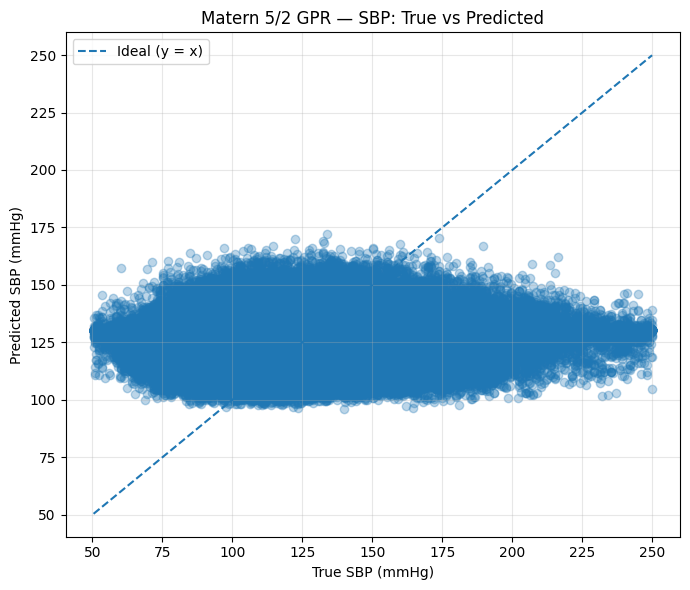

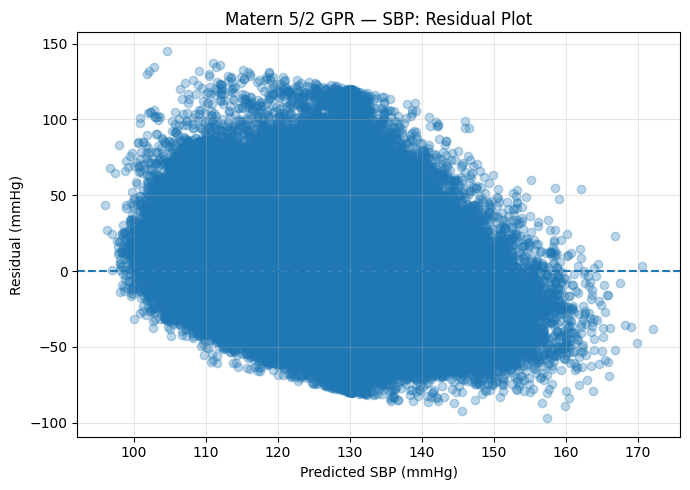

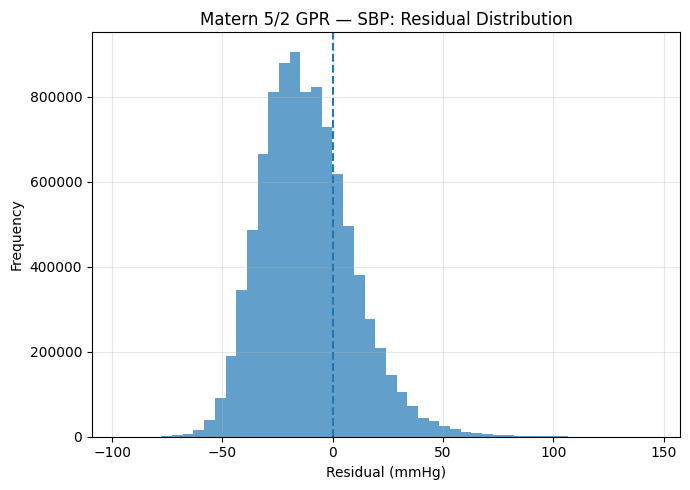

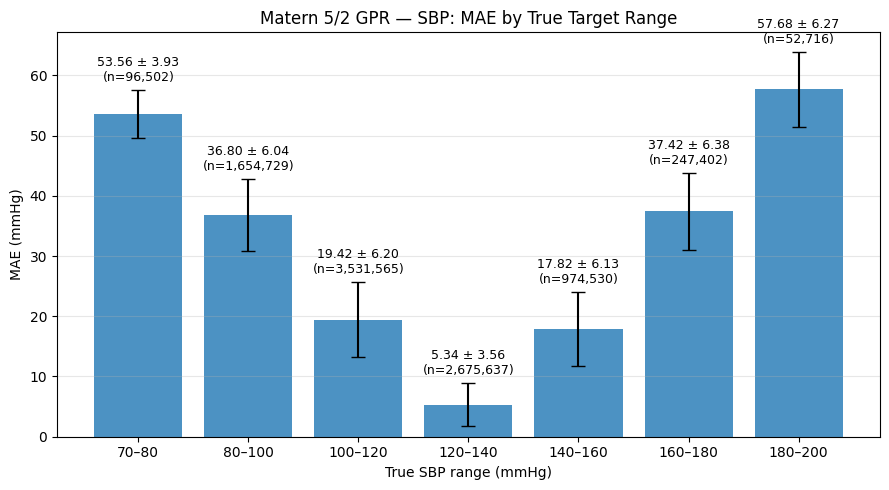

In [28]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

GPR training samples: 5,000

Starting Rational Quadratic GPR GridSearch...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)}

Best CV RMSE: 18.51898841372948

Best GPR model:
GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1),
                         normalize_y=True, random_state=42)

Starting batched prediction on 105,176 samples...
RMSE: 19.8071
MSE : 392.3214
R²  : 0.2568
MAE : 15.3284


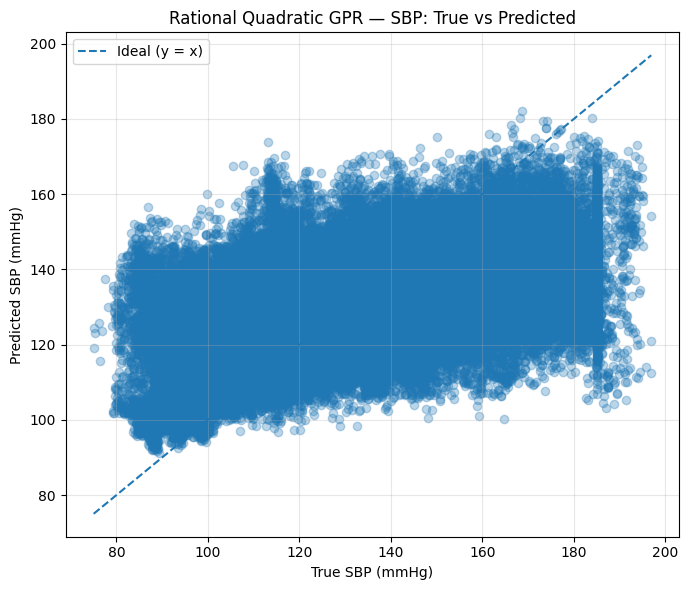

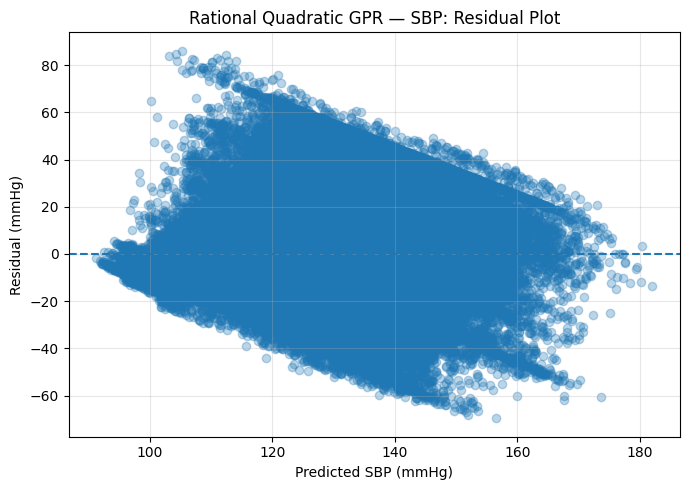

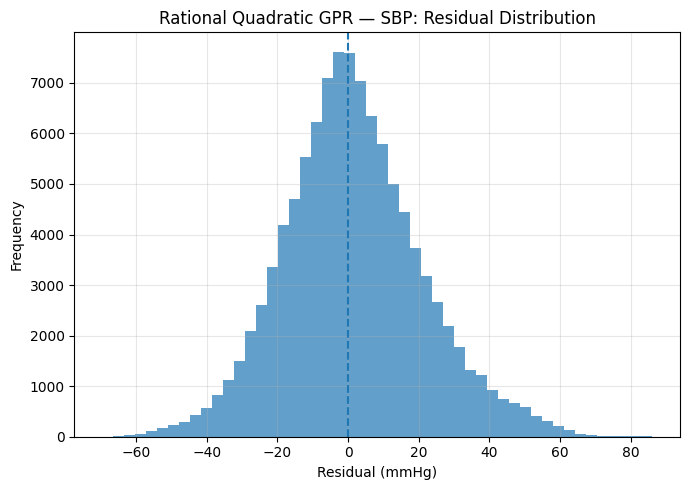

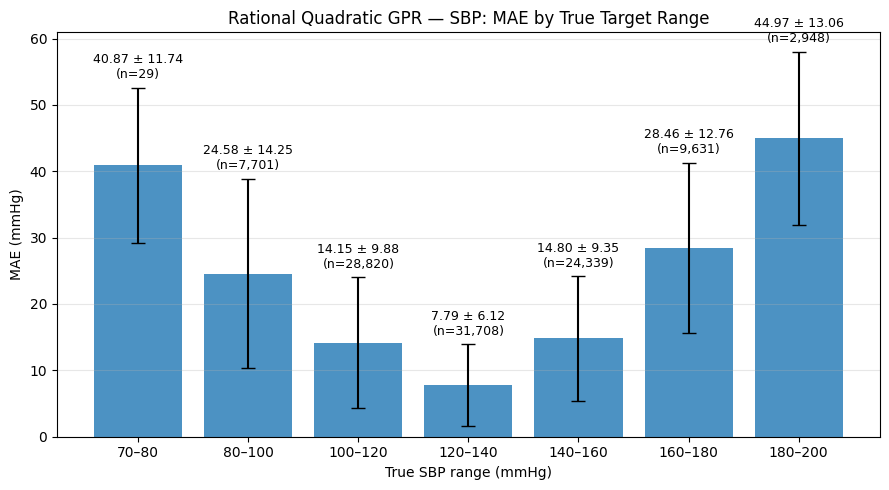

In [29]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 22.2973
MSE : 497.1680
R²  : -0.1632
MAE : 18.0765


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


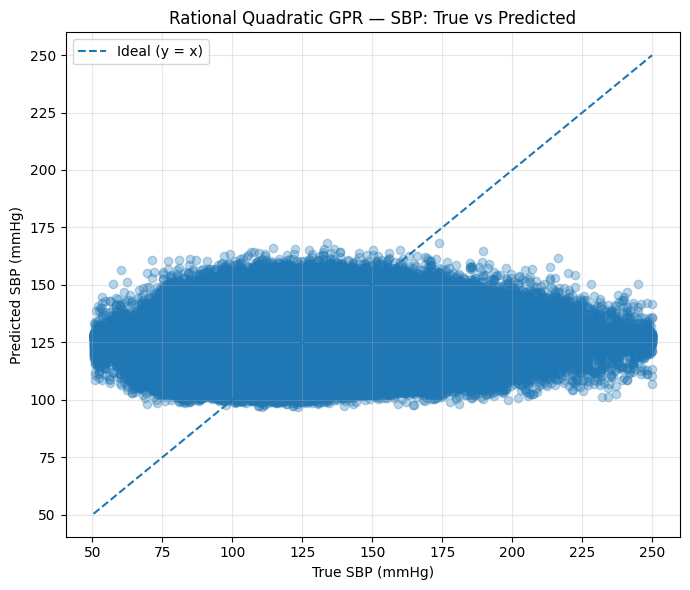

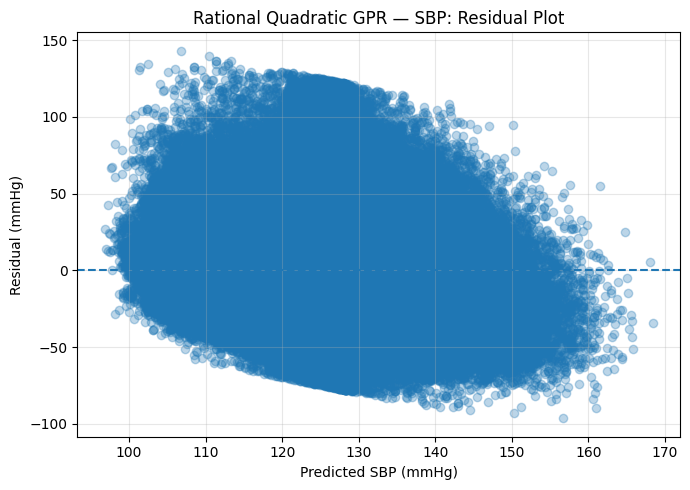

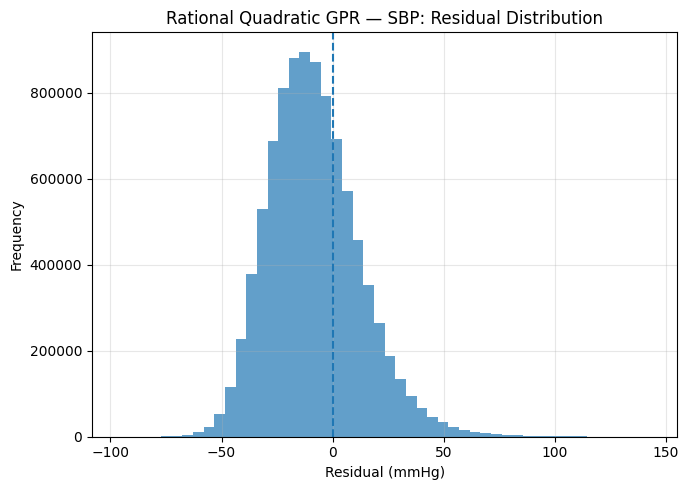

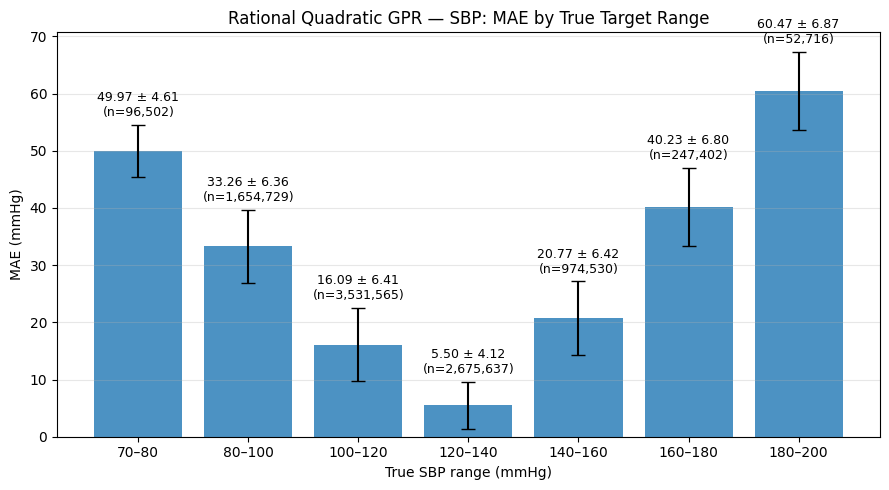

In [30]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.01, 'batch_size': 512, 'hidden_layer_sizes': (64, 32, 16), 'learning_rate_init': 0.01}

Best CV RMSE: 20.032138968998854

Best ANN / MLP model:
MLPRegressor(alpha=0.01, batch_size=512, early_stopping=True,
             hidden_layer_sizes=(64, 32, 16), learning_rate_init=0.01,
             max_iter=300, n_iter_no_change=20, random_state=42)

Starting batched prediction on 105,176 samples...
Processed 10,000 / 105,176
Processed 20,000 / 105,176
Processed 30,000 / 105,176
Processed 40,000 / 105,176
Processed 50,000 / 105,176
Processed 60,000 / 105,176
Processed 70,000 / 105,176
Processed 80,000 / 105,176
Processed 90,000 / 105,176
Processed 100,000 / 105,176
Processed 105,176 / 105,176

ANN / MLP Regressor — SBP
------------------------------------
RMSE: 21.0119
MSE : 441.5019
R²  : 0.1636
MAE : 16.1906


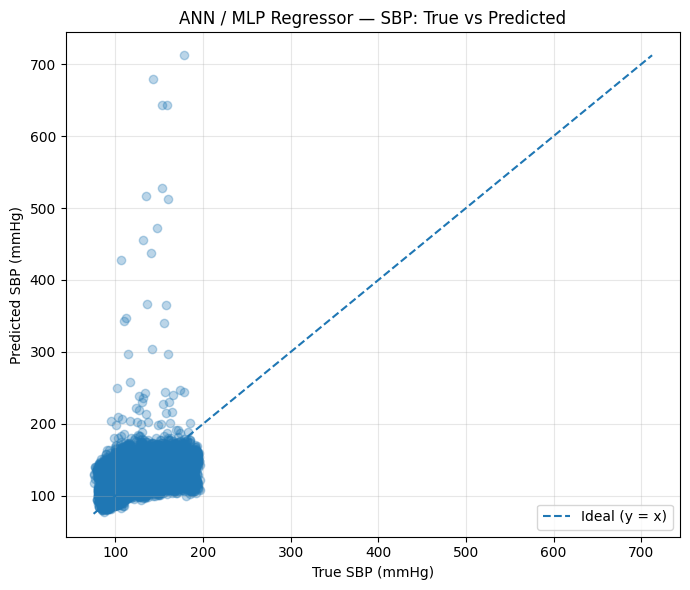

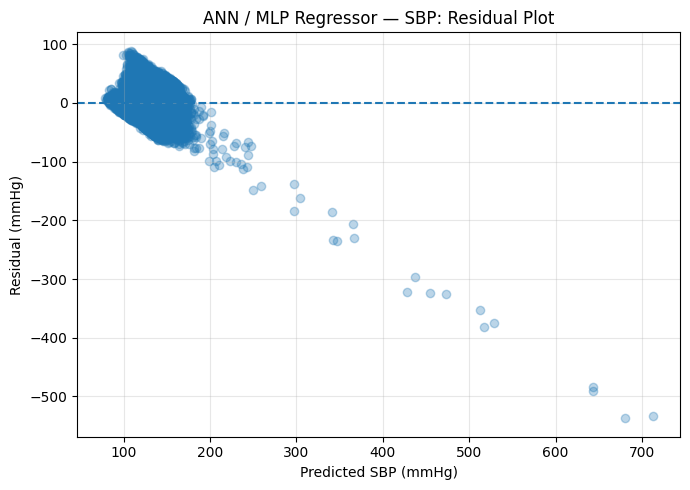

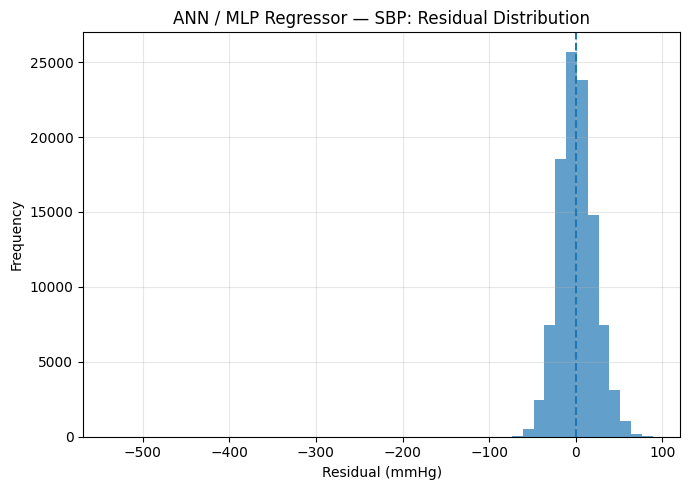

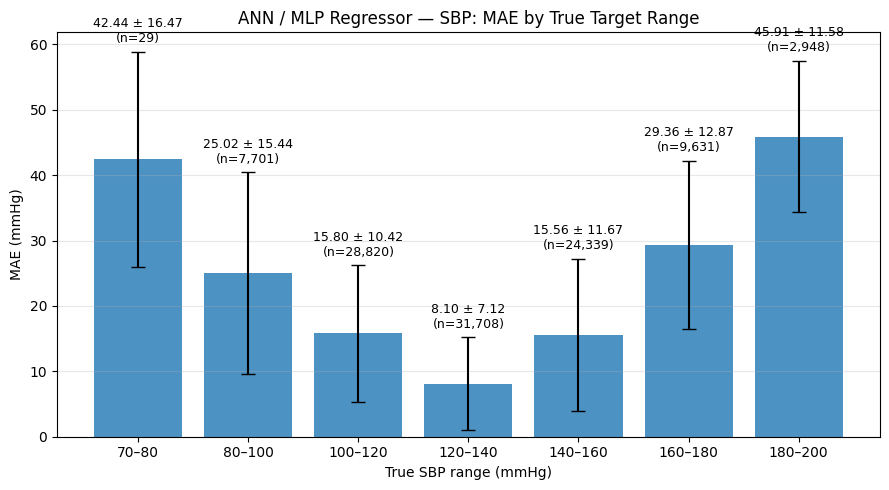

In [31]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 505.6247
MSE : 255656.3313
R²  : -597.1633
MAE : 225.2245


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/5sec_50%overlap/ftest/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


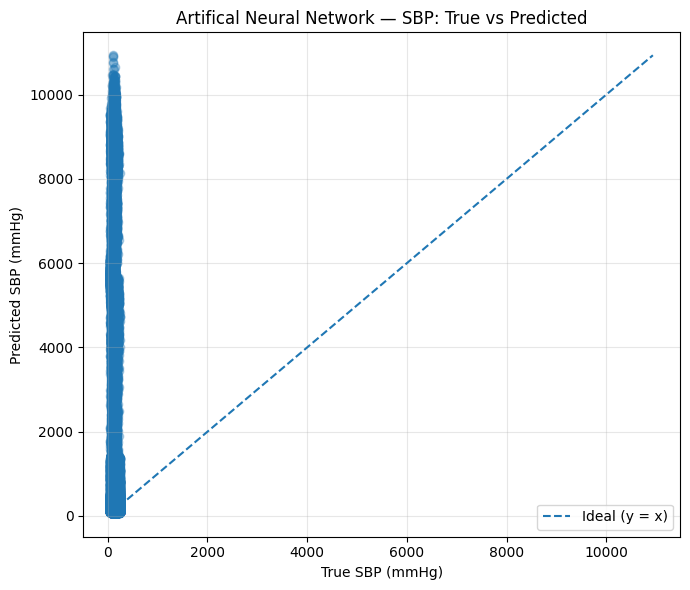

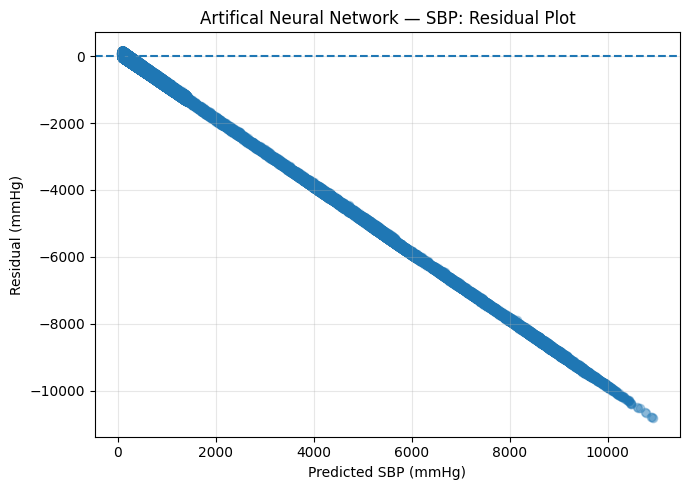

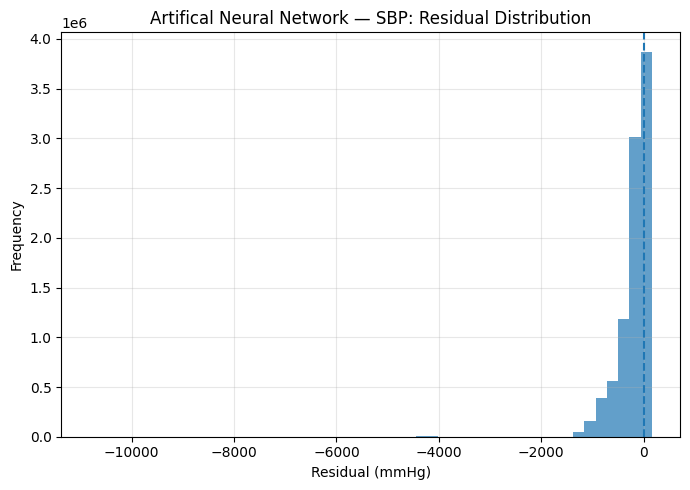

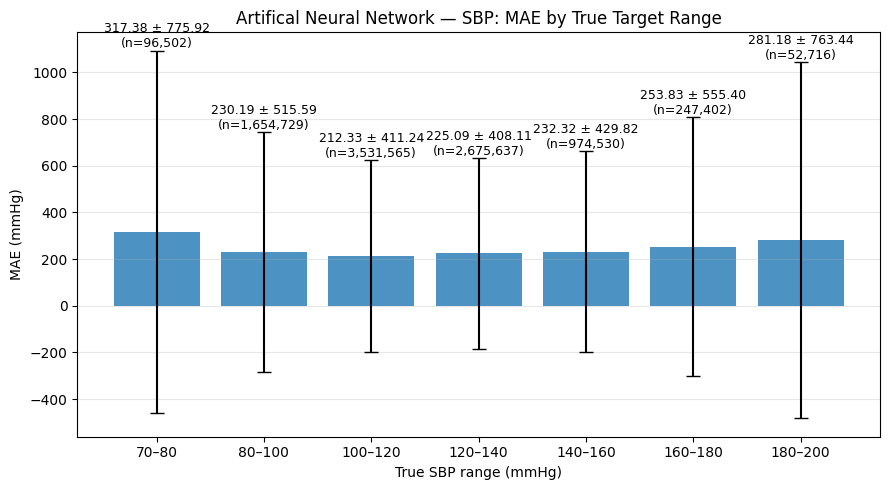

In [32]:
y_pred_vitaldb = predict_gpr_in_batches(
    ann_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)